# Final Project: Stardew Maximizing Profits

# EDA

Imports

In [ ]:
import json
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import xml.etree.ElementTree as ET
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler, StandardScaler

## Loading Files

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
animals = pd.read_json("/content/drive/MyDrive/ML Final Project/animals.json")
animals.columns

Index(['type', 'id', 'name', 'variant', 'purchasePrice', 'image',
       'description', 'building', 'sellPrice', 'daysToMature', 'daysToProduce',
       'harvestMethod', 'harvestTool', 'produce', 'deluxeProduce'],
      dtype='object')

In [ ]:
crops = pd.read_json("/content/drive/MyDrive/ML Final Project/crops.json")
crops.columns

Index(['id', 'name', 'category', 'seasons', 'growDays', 'regrowDays', 'seedId',
       'seedName', 'seedBuyPrices', 'seedSellPrice', 'cropSellPrice',
       'profession', 'harvestQuantity', 'trellis', 'giant', 'description',
       'image', 'seedImage', 'stages', 'energyHealth', 'farmingXP',
       'maxQuality', 'artisanUses', 'giantImage'],
      dtype='object')

In [ ]:
artisan = pd.read_json("/content/drive/MyDrive/ML Final Project/artisan-goods.json")
artisan.columns

Index(['id', 'name', 'description', 'equipment', 'ingredients',
       'processingMinutes', 'processingDays', 'sellPrice', 'profession',
       'sellPriceFormula', 'priceFormula', 'qualityLevels', 'cask',
       'energyHealthFormula', 'energyHealth', 'buffs', 'buffDuration', 'image',
       'maxQuality'],
      dtype='object')

In [ ]:
fish = pd.read_json("/content/drive/MyDrive/ML Final Project/fish.json")
fish.columns

Index(['id', 'name', 'description', 'catchType', 'category', 'seasons',
       'location', 'weather', 'time', 'difficulty', 'sellPrice', 'profession',
       'fishTank', 'usedIn', 'energyHealth', 'maxQuality', 'image', 'canSmoke',
       'roe', 'fishPond'],
      dtype='object')

In [ ]:
game_file = "/content/drive/MyDrive/ML Final Project/Plushie_432431937"

In [ ]:
silver_multiplier = 1.25
gold_multiplier = 1.5
iridium_multiplier = 2

## Animal Data

In [ ]:
# Stores extracted produce names and their base sell prices
produce_names = []
regular_prices = []

# Pulls name/price out of nested produce data into clean columns
for value in animals["produce"]:
    if isinstance(value, dict):
      produce_names.append(value.get("name"))
      regular_prices.append(value.get("sellPrice"))
    else:
      produce_names.append(None)
      regular_prices.append(None)

# Adds the extracted data as new columns
animals["produceName"] = produce_names
animals["sellPrice"] = regular_prices

# Store prices adjusted by quality multipliers
silver_prices = []
gold_prices = []
iridium_prices = []

# Loops through the base sell prices we just created
for value in animals["sellPrice"]:
    if pd.notnull(value):
      silver_prices.append(int(value * silver_multiplier))
      gold_prices.append(int(value * gold_multiplier))
      iridium_prices.append(int(value * iridium_multiplier))
    else:
      # If no base price exists, then None
      silver_prices.append(None)
      gold_prices.append(None)
      iridium_prices.append(None)

# Adds new columns for each quality tier
animals["silverPrice"] = silver_prices
animals["goldPrice"] = gold_prices
animals["iridiumPrice"] = iridium_prices

In [ ]:
# Remove rows
animals = animals[animals["type"] != "pet"]

# Renaming for cleaner data
animals['name'] = animals['name'] + " " + animals['produceName'].str.split().str[-1]

# Renaming "type" to "category"
animals = animals.rename(columns = {"type" : "category"})

# Rename "daysToProduce" to "growDays"
animals = animals.rename(columns={'daysToProduce' : 'growDays'})

# Creates a new columns
animals['regrowDays'] = animals['growDays'] + 1
animals["harvest_frequency"] = ((28 - animals["daysToMature"]) // animals["regrowDays"]) + 1

# Pig harvest_quantity_average is 3
animals.loc[animals["name"] == "Pig Truffle", "harvest_quantity_average"] = 3

# Pigs seasons its able to produce
animals["seasons"] = None
pig_index = animals.loc[animals["name"] == "Pig Truffle"].index[0]
animals.at[pig_index, "seasons"] = ["spring", "summer", "fall"]

# white chicken egg, brown chicken  egg, blue egg, void egg, gold egg, duck egg, rabbit wool, dino egg, white cow milk, brown cow milk, goat milk, sheep wool, pig truffle, ostrich egg
ids = [176, 180, 176, 305, 982, 442, 440, 107, 184, 184, 436, 440, 430, 289]
animals["id"] = ids

# Drop Columns
animals_drop_columns = ['variant', 'purchasePrice', 'image', 'description', 'building', 'daysToMature', 'harvestMethod', 'harvestTool', 'produce', 'deluxeProduce', 'produceName']
animals = animals.drop(columns=animals_drop_columns, errors='ignore')

In [ ]:
animals

,category,id,name,sellPrice,growDays,silverPrice,goldPrice,iridiumPrice,regrowDays,harvest_frequency,harvest_quantity_average,seasons
13,farm-animal,176,White Chicken Egg,50.0,1.0,62.0,75.0,100.0,2.0,13.0,NaN,None
14,farm-animal,180,Brown Chicken Egg,50.0,1.0,62.0,75.0,100.0,2.0,13.0,NaN,None
15,farm-animal,176,Blue Chicken Egg,50.0,1.0,62.0,75.0,100.0,2.0,13.0,NaN,None
16,farm-animal,305,Void Chicken Egg,65.0,1.0,81.0,97.0,130.0,2.0,13.0,NaN,None
17,farm-animal,982,Golden Chicken Egg,500.0,1.0,625.0,750.0,1000.0,2.0,13.0,NaN,None
18,farm-animal,442,Duck Egg,95.0,2.0,118.0,142.0,190.0,3.0,8.0,NaN,None
19,farm-animal,440,Rabbit Wool,340.0,4.0,425.0,510.0,680.0,5.0,5.0,NaN,None
20,farm-animal,107,Dinosaur Egg,350.0,7.0,437.0,525.0,700.0,8.0,4.0,NaN,None
21,farm-animal,184,White Cow Milk,125.0,1.0,156.0,187.0,250.0,2.0,12.0,NaN,None
22,farm-animal,184,Brown Cow Milk,125.0,1.0,156.0,187.0,250.0,2.0,12.0,NaN,None


**Process**
- For animals we converted a JSON file containing animal data into a structured CSV file for easier analysis. The original JSON file had nestedt fields such as "produce", which stored information like name and sell price.
- To prepare the data, we extracted relevant values from these nested structures, specifically pulling out "produce.name" and "produce.sellPrice" into separate columns for easier access.
- We also cleaned the dataset by excluding unwanted animals. Specifically, we removed all animals with type = "pet" (such as cats, dogs, turtles, iridium turtles, and horses). This ensured that only farm animals remained in the final dataset.
- Preprocessing steps included renaming columns for consistency, calculating production timing (such as regrow days), and including associated produce to animals.
- Finally, unnecessary columns were removed to simplify the dataset, resulting in a clean DataFrame ready for profitability analysis.

## Crop Data

In [ ]:
crop_drop_columns = ['seedId', 'seedName', 'seedBuyPrices', 'seedSellPrice', 'profession', 'trellis', 'giant', 'description', 'image', 'seedImage', 'stages', 'energyHealth', 'farmingXP', 'giantImage']
crops = crops.drop(crop_drop_columns, axis=1)
crops = crops[crops["name"] != "Ancient Fruit"]
crops.columns

Index(['id', 'name', 'category', 'seasons', 'growDays', 'regrowDays',
       'cropSellPrice', 'harvestQuantity', 'maxQuality', 'artisanUses'],
      dtype='object')

In [ ]:
crops = crops.rename(columns={'cropSellPrice' : 'sellPrice'})

In [ ]:
crops.head(5)

,id,name,category,seasons,growDays,regrowDays,sellPrice,harvestQuantity,maxQuality,artisanUses
0,24,Parsnip,vegetable,[spring],4,NaN,35,"{'min': 1, 'max': 1}",iridium,"{'honey': False, 'wine': False, 'juice': True,..."
1,188,Green Bean,vegetable,[spring],10,3.0,40,"{'min': 1, 'max': 1}",iridium,"{'honey': False, 'wine': False, 'juice': True,..."
2,190,Cauliflower,vegetable,[spring],12,NaN,175,"{'min': 1, 'max': 1}",iridium,"{'honey': False, 'wine': False, 'juice': True,..."
3,192,Potato,vegetable,[spring],6,NaN,80,"{'min': 1, 'max': 4}",iridium,"{'honey': False, 'wine': False, 'juice': True,..."
4,248,Garlic,vegetable,[spring],4,NaN,60,"{'min': 1, 'max': 1}",iridium,"{'honey': False, 'wine': False, 'juice': True,..."


In [ ]:
# If the regrow column is empty, fill it with the grow column (game correct) and add 1 to the grow columns (game correct)
crops['regrowDays'] = crops['regrowDays'].fillna(crops['growDays'])
crops['growDays'] = crops['growDays'] + 1


In [ ]:
season_length = 28

# Adding 1 because it takes one more day to grow when the crop is first planted
crops['growDays'] = crops['growDays'].fillna(crops['regrowDays'])

# Adding 1 because it needs to include the very first harvest after planting
crops['harvest_frequency'] = 1 + ((season_length - (crops['growDays'])) // crops['regrowDays'])

crops.head(5)

,id,name,category,seasons,growDays,regrowDays,sellPrice,harvestQuantity,maxQuality,artisanUses,harvest_frequency
0,24,Parsnip,vegetable,[spring],5,4.0,35,"{'min': 1, 'max': 1}",iridium,"{'honey': False, 'wine': False, 'juice': True,...",6.0
1,188,Green Bean,vegetable,[spring],11,3.0,40,"{'min': 1, 'max': 1}",iridium,"{'honey': False, 'wine': False, 'juice': True,...",6.0
2,190,Cauliflower,vegetable,[spring],13,12.0,175,"{'min': 1, 'max': 1}",iridium,"{'honey': False, 'wine': False, 'juice': True,...",2.0
3,192,Potato,vegetable,[spring],7,6.0,80,"{'min': 1, 'max': 4}",iridium,"{'honey': False, 'wine': False, 'juice': True,...",4.0
4,248,Garlic,vegetable,[spring],5,4.0,60,"{'min': 1, 'max': 1}",iridium,"{'honey': False, 'wine': False, 'juice': True,...",6.0


In [ ]:
crops['harvest_quantity_average'] = crops['harvestQuantity'].apply(lambda x: (x['min'] + x['max']) / 2)
crops = crops.drop('harvestQuantity', axis = 1)

In [ ]:
crops.head(5)

,id,name,category,seasons,growDays,regrowDays,sellPrice,maxQuality,artisanUses,harvest_frequency,harvest_quantity_average
0,24,Parsnip,vegetable,[spring],5,4.0,35,iridium,"{'honey': False, 'wine': False, 'juice': True,...",6.0,1.0
1,188,Green Bean,vegetable,[spring],11,3.0,40,iridium,"{'honey': False, 'wine': False, 'juice': True,...",6.0,1.0
2,190,Cauliflower,vegetable,[spring],13,12.0,175,iridium,"{'honey': False, 'wine': False, 'juice': True,...",2.0,1.0
3,192,Potato,vegetable,[spring],7,6.0,80,iridium,"{'honey': False, 'wine': False, 'juice': True,...",4.0,2.5
4,248,Garlic,vegetable,[spring],5,4.0,60,iridium,"{'honey': False, 'wine': False, 'juice': True,...",6.0,1.0


In [ ]:
qualilty_cols = ['silverPrice', 'goldPrice', 'iridiumPrice']

crops[qualilty_cols[0]] = crops['sellPrice'] * silver_multiplier
crops[qualilty_cols[1]] = crops['sellPrice'] * gold_multiplier
crops[qualilty_cols[2]] = crops['sellPrice'] * iridium_multiplier

crops.head(5)

,id,name,category,seasons,growDays,regrowDays,sellPrice,maxQuality,artisanUses,harvest_frequency,harvest_quantity_average,silverPrice,goldPrice,iridiumPrice
0,24,Parsnip,vegetable,[spring],5,4.0,35,iridium,"{'honey': False, 'wine': False, 'juice': True,...",6.0,1.0,43.75,52.5,70
1,188,Green Bean,vegetable,[spring],11,3.0,40,iridium,"{'honey': False, 'wine': False, 'juice': True,...",6.0,1.0,50.00,60.0,80
2,190,Cauliflower,vegetable,[spring],13,12.0,175,iridium,"{'honey': False, 'wine': False, 'juice': True,...",2.0,1.0,218.75,262.5,350
3,192,Potato,vegetable,[spring],7,6.0,80,iridium,"{'honey': False, 'wine': False, 'juice': True,...",4.0,2.5,100.00,120.0,160
4,248,Garlic,vegetable,[spring],5,4.0,60,iridium,"{'honey': False, 'wine': False, 'juice': True,...",6.0,1.0,75.00,90.0,120


In [ ]:
# Creating for the Artisan part of the dataset
artisan_cols = ['honey', 'wine', 'juice', 'pickles', 'jelly', 'driedMushrooms', 'driedFruit']

crops[artisan_cols] = crops['artisanUses'].apply(pd.Series)
crops.columns

Index(['id', 'name', 'category', 'seasons', 'growDays', 'regrowDays',
       'sellPrice', 'maxQuality', 'artisanUses', 'harvest_frequency',
       'harvest_quantity_average', 'silverPrice', 'goldPrice', 'iridiumPrice',
       'honey', 'wine', 'juice', 'pickles', 'jelly', 'driedMushrooms',
       'driedFruit'],
      dtype='object')

In [ ]:
crops = crops.drop(['artisanUses', 'maxQuality'], axis=1)

In [ ]:
crops

,id,name,category,seasons,growDays,regrowDays,sellPrice,harvest_frequency,harvest_quantity_average,silverPrice,goldPrice,iridiumPrice,honey,wine,juice,pickles,jelly,driedMushrooms,driedFruit
0,24,Parsnip,vegetable,[spring],5,4.0,35,6.0,1.0,43.75,52.5,70,False,False,True,True,False,False,False
1,188,Green Bean,vegetable,[spring],11,3.0,40,6.0,1.0,50.00,60.0,80,False,False,True,True,False,False,False
2,190,Cauliflower,vegetable,[spring],13,12.0,175,2.0,1.0,218.75,262.5,350,False,False,True,True,False,False,False
3,192,Potato,vegetable,[spring],7,6.0,80,4.0,2.5,100.00,120.0,160,False,False,True,True,False,False,False
4,248,Garlic,vegetable,[spring],5,4.0,60,6.0,1.0,75.00,90.0,120,False,False,True,True,False,False,False
5,250,Kale,vegetable,[spring],7,6.0,110,4.0,1.0,137.50,165.0,220,False,False,True,True,False,False,False
6,252,Rhubarb,fruit,[spring],14,13.0,220,2.0,1.0,275.00,330.0,440,False,True,False,False,True,False,True
7,400,Strawberry,fruit,[spring],9,4.0,120,5.0,1.0,150.00,180.0,240,False,True,False,False,True,False,True
8,271,Unmilled Rice,vegetable,[spring],9,8.0,30,3.0,1.0,37.50,45.0,60,False,False,False,False,False,False,False
9,591,Tulip,flower,[spring],7,6.0,30,4.0,1.0,37.50,45.0,60,True,False,False,False,False,False,False


## Artisan Data

In [ ]:
# Stores adjusted prices for different quality levels
silver_prices = []
gold_prices = []
iridium_prices = []

# Only these artisan goods have quality variations
quality_items = ['Cheese', 'Goat Cheese', 'Mayonnaise']

# Loops through each item's name and base sell price together
for name, value in zip(artisan["name"], artisan["sellPrice"]):
    if name in quality_items and pd.notnull(value):
      silver_prices.append(int(value * silver_multiplier))
      gold_prices.append(int(value * gold_multiplier))
      iridium_prices.append(int(value * iridium_multiplier))
    else:
      # If item doesn't have quality levels, set values to 0
      silver_prices.append(0)
      gold_prices.append(0)
      iridium_prices.append(0)

# Adds new columns for each quality tier
artisan["silverPrice"] = silver_prices
artisan["goldPrice"] = gold_prices
artisan["iridiumPrice"] = iridium_prices

# Labels all rows as "artisan" category for later grouping/analysis
artisan["category"] = 'artisan'

In [ ]:
# List of artisan items we want to keep for analysis
keep_items = ['Cheese', 'Goat Cheese', 'Mayonnaise', 'Cloth', 'Truffle Oil', 'Duck Mayonnaise', 'Void Mayonnaise', 'Dinosaur Mayonnaise']

# Filters dataframe to only keep keep_items
artisan = artisan[artisan["name"].isin(keep_items)]

# Renaming for cleaner data
artisan = artisan.rename(columns = {"processingDays" : "growDays"})

# Removes Column
artisan = artisan.drop('processingMinutes', axis = 1)

# reGrowDays
artisan['regrowDays'] = artisan['growDays']

# Drops columns
artisan_drop_columns = ['description', 'equipment', 'ingredients', 'profession', 'sellPriceFormula', 'priceFormula', 'qualityLevels', 'cask', 'energyHealthFormula', 'energyHealth', 'buffs', 'buffDuration', 'image', 'maxQuality']
artisan = artisan.drop(columns=artisan_drop_columns, errors='ignore')
artisan.columns

Index(['id', 'name', 'growDays', 'sellPrice', 'silverPrice', 'goldPrice',
       'iridiumPrice', 'category', 'regrowDays'],
      dtype='object')

In [ ]:
artisan

,id,name,growDays,sellPrice,silverPrice,goldPrice,iridiumPrice,category,regrowDays
13,424,Cheese,0.13,230.0,287,345,460,artisan,0.13
14,426,Goat Cheese,0.13,400.0,500,600,800,artisan,0.13
15,428,Cloth,0.15,470.0,0,0,0,artisan,0.15
16,432,Truffle Oil,0.23,1065.0,0,0,0,artisan,0.23
18,306,Mayonnaise,0.11,190.0,237,285,380,artisan,0.11
19,307,Duck Mayonnaise,0.11,375.0,0,0,0,artisan,0.11
20,308,Void Mayonnaise,0.11,275.0,0,0,0,artisan,0.11
21,807,Dinosaur Mayonnaise,0.11,800.0,0,0,0,artisan,0.11


In [ ]:
# Adjusting the different types of honey
honey_rows = crops[crops['honey']].copy()

# Update the name column to indicate these are honey versions of the items
honey_rows['name'] = honey_rows['name'] + " Honey"

honey_rows['sellPrice'] = 100 + (honey_rows['sellPrice'] * 2)

honey_rows

,id,name,category,seasons,growDays,regrowDays,sellPrice,harvest_frequency,harvest_quantity_average,silverPrice,goldPrice,iridiumPrice,honey,wine,juice,pickles,jelly,driedMushrooms,driedFruit
9,591,Tulip Honey,flower,[spring],7,6.0,160,4.0,1.0,37.5,45.0,60,True,False,False,False,False,False,False
10,597,Blue Jazz Honey,flower,[spring],8,7.0,200,3.0,1.0,62.5,75.0,100,True,False,False,False,False,False,False
21,376,Poppy Honey,flower,[summer],8,7.0,380,3.0,1.0,175.0,210.0,280,True,False,False,False,False,False,False
22,593,Summer Spangle Honey,flower,[summer],9,8.0,280,3.0,1.0,112.5,135.0,180,True,False,False,False,False,False,False
27,421,Sunflower Honey,flower,"[summer, fall]",9,8.0,260,3.0,1.0,100.0,120.0,160,True,False,False,False,False,False,False
38,595,Fairy Rose Honey,flower,[fall],13,12.0,680,2.0,1.0,362.5,435.0,580,True,False,False,False,False,False,False


In [ ]:
# Setting the number of days it takes for the honey item to grow plus the days it takes to produce honey
honey_rows['growDays'] = honey_rows['growDays'] + 4
honey_rows['regrowDays'] = honey_rows['growDays']

# Set all quality-related columns to 0 for honey items
honey_rows[qualilty_cols] = 0

# Adjusting the harvest_frequency
honey_rows['harvest_frequency'] = 1 + ((season_length - honey_rows['growDays']) // honey_rows['regrowDays'])

# Setting the category to be artisan
honey_rows['category'] = "artisan"

# Combine the original artisan dataframe with the new honey rows
artisan = pd.concat([artisan, honey_rows], ignore_index=True)

artisan

,id,name,growDays,sellPrice,silverPrice,goldPrice,iridiumPrice,category,regrowDays,seasons,harvest_frequency,harvest_quantity_average,honey,wine,juice,pickles,jelly,driedMushrooms,driedFruit
0,424,Cheese,0.13,230.0,287,345,460,artisan,0.13,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,426,Goat Cheese,0.13,400.0,500,600,800,artisan,0.13,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,428,Cloth,0.15,470.0,0,0,0,artisan,0.15,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,432,Truffle Oil,0.23,1065.0,0,0,0,artisan,0.23,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,306,Mayonnaise,0.11,190.0,237,285,380,artisan,0.11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,307,Duck Mayonnaise,0.11,375.0,0,0,0,artisan,0.11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,308,Void Mayonnaise,0.11,275.0,0,0,0,artisan,0.11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,807,Dinosaur Mayonnaise,0.11,800.0,0,0,0,artisan,0.11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,591,Tulip Honey,11.00,160.0,0,0,0,artisan,11.00,[spring],2.0,1.0,True,False,False,False,False,False,False
9,597,Blue Jazz Honey,12.00,200.0,0,0,0,artisan,12.00,[spring],2.0,1.0,True,False,False,False,False,False,False


In [ ]:
# Select only the crops that can be turned into wine
wine_rows = crops[crops['wine']].copy()

# Set the sell price to be 3x base crop price
wine_rows['sellPrice'] = wine_rows['sellPrice'] * 3

# Set all quality-related columns to 0 for honey items
wine_rows[qualilty_cols] = 0

# Setting the number of days it takes for the wine to "grow", assuming the crop was already harvested once
wine_rows['growDays'] = wine_rows['regrowDays'] + 7
wine_rows['regrowDays'] = wine_rows['growDays']

# Adjusting the harvest_frequency
wine_rows['harvest_frequency'] = 1 + ((season_length - wine_rows['growDays']) // wine_rows['regrowDays'])

# Renaming the items
wine_rows['name'] = wine_rows['name'] + " Wine"

# Setting the category to be artisan
wine_rows['category'] = "artisan"

In [ ]:
# Combine the original artisan dataframe with the new wine rows
artisan = pd.concat([artisan, wine_rows], ignore_index=True)

In [ ]:
artisan

,id,name,growDays,sellPrice,silverPrice,goldPrice,iridiumPrice,category,regrowDays,seasons,harvest_frequency,harvest_quantity_average,honey,wine,juice,pickles,jelly,driedMushrooms,driedFruit
0,424,Cheese,0.13,230.0,287,345,460,artisan,0.13,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,426,Goat Cheese,0.13,400.0,500,600,800,artisan,0.13,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,428,Cloth,0.15,470.0,0,0,0,artisan,0.15,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,432,Truffle Oil,0.23,1065.0,0,0,0,artisan,0.23,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,306,Mayonnaise,0.11,190.0,237,285,380,artisan,0.11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,307,Duck Mayonnaise,0.11,375.0,0,0,0,artisan,0.11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,308,Void Mayonnaise,0.11,275.0,0,0,0,artisan,0.11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,807,Dinosaur Mayonnaise,0.11,800.0,0,0,0,artisan,0.11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,591,Tulip Honey,11.00,160.0,0,0,0,artisan,11.00,[spring],2.0,1.0,True,False,False,False,False,False,False
9,597,Blue Jazz Honey,12.00,200.0,0,0,0,artisan,12.00,[spring],2.0,1.0,True,False,False,False,False,False,False


In [ ]:
# Select only the crops that can be turned into juice
juice_rows = crops[crops['juice']].copy()
juice_rows.head(3)

,id,name,category,seasons,growDays,regrowDays,sellPrice,harvest_frequency,harvest_quantity_average,silverPrice,goldPrice,iridiumPrice,honey,wine,juice,pickles,jelly,driedMushrooms,driedFruit
0,24,Parsnip,vegetable,[spring],5,4.0,35,6.0,1.0,43.75,52.5,70,False,False,True,True,False,False,False
1,188,Green Bean,vegetable,[spring],11,3.0,40,6.0,1.0,50.00,60.0,80,False,False,True,True,False,False,False
2,190,Cauliflower,vegetable,[spring],13,12.0,175,2.0,1.0,218.75,262.5,350,False,False,True,True,False,False,False


In [ ]:
# Set the sell price
juice_rows['sellPrice'] = juice_rows['sellPrice'] * 2.25

# Set all quality-related columns to 0 for crop items since quality of item doesn't transfer when making it
juice_rows[qualilty_cols] = 0

# Setting the number of days it takes for the juice to "grow"
juice_rows['growDays'] = juice_rows['regrowDays'] + 4
juice_rows['regrowDays'] = juice_rows['growDays']

# Renaming the items
juice_rows['name'] = juice_rows['name'] + " Juice"

# Adjusting the harvest_frequency
juice_rows['harvest_frequency'] = 1 + ((season_length - juice_rows['growDays']) // juice_rows['regrowDays'])

# Setting the category to be artisan
juice_rows['category'] = "artisan"

In [ ]:
juice_rows.head(2)

,id,name,category,seasons,growDays,regrowDays,sellPrice,harvest_frequency,harvest_quantity_average,silverPrice,goldPrice,iridiumPrice,honey,wine,juice,pickles,jelly,driedMushrooms,driedFruit
0,24,Parsnip Juice,artisan,[spring],8.0,8.0,78.75,3.0,1.0,0,0,0,False,False,True,True,False,False,False
1,188,Green Bean Juice,artisan,[spring],7.0,7.0,90.00,4.0,1.0,0,0,0,False,False,True,True,False,False,False


In [ ]:
# Combine the original artisan dataframe with the new juice rows
artisan = pd.concat([artisan, juice_rows], ignore_index=True)

In [ ]:
artisan

,id,name,growDays,sellPrice,silverPrice,goldPrice,iridiumPrice,category,regrowDays,seasons,harvest_frequency,harvest_quantity_average,honey,wine,juice,pickles,jelly,driedMushrooms,driedFruit
0,424,Cheese,0.13,230.00,287,345,460,artisan,0.13,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,426,Goat Cheese,0.13,400.00,500,600,800,artisan,0.13,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,428,Cloth,0.15,470.00,0,0,0,artisan,0.15,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,432,Truffle Oil,0.23,1065.00,0,0,0,artisan,0.23,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,306,Mayonnaise,0.11,190.00,237,285,380,artisan,0.11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,307,Duck Mayonnaise,0.11,375.00,0,0,0,artisan,0.11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,308,Void Mayonnaise,0.11,275.00,0,0,0,artisan,0.11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,807,Dinosaur Mayonnaise,0.11,800.00,0,0,0,artisan,0.11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,591,Tulip Honey,11.00,160.00,0,0,0,artisan,11.00,[spring],2.0,1.0,True,False,False,False,False,False,False
9,597,Blue Jazz Honey,12.00,200.00,0,0,0,artisan,12.00,[spring],2.0,1.0,True,False,False,False,False,False,False


In [ ]:
# Select only the crops that can be pickled
pickle_rows = crops[crops['pickles']].copy()
pickle_rows.head(3)

,id,name,category,seasons,growDays,regrowDays,sellPrice,harvest_frequency,harvest_quantity_average,silverPrice,goldPrice,iridiumPrice,honey,wine,juice,pickles,jelly,driedMushrooms,driedFruit
0,24,Parsnip,vegetable,[spring],5,4.0,35,6.0,1.0,43.75,52.5,70,False,False,True,True,False,False,False
1,188,Green Bean,vegetable,[spring],11,3.0,40,6.0,1.0,50.00,60.0,80,False,False,True,True,False,False,False
2,190,Cauliflower,vegetable,[spring],13,12.0,175,2.0,1.0,218.75,262.5,350,False,False,True,True,False,False,False


In [ ]:
# Set the sell price
pickle_rows['sellPrice'] = 50 + (pickle_rows['sellPrice'] * 2)

# Set all quality-related columns to 0 for honey items
pickle_rows[qualilty_cols] = 0

# Setting the number of days it takes for the juice to "grow"
pickle_rows['growDays'] = pickle_rows['regrowDays'] + 3
pickle_rows['regrowDays'] = pickle_rows['growDays']

# Renaming the items
pickle_rows['name'] = pickle_rows['name'] + " Pickle"

# Adjusting the harvest_frequency
pickle_rows['harvest_frequency'] = 1 + ((season_length - pickle_rows['growDays']) // pickle_rows['regrowDays'])

# Setting the category to be artisan
pickle_rows['category'] = "artisan"

In [ ]:
pickle_rows.head(3)

,id,name,category,seasons,growDays,regrowDays,sellPrice,harvest_frequency,harvest_quantity_average,silverPrice,goldPrice,iridiumPrice,honey,wine,juice,pickles,jelly,driedMushrooms,driedFruit
0,24,Parsnip Pickle,artisan,[spring],7.0,7.0,120,4.0,1.0,0,0,0,False,False,True,True,False,False,False
1,188,Green Bean Pickle,artisan,[spring],6.0,6.0,130,4.0,1.0,0,0,0,False,False,True,True,False,False,False
2,190,Cauliflower Pickle,artisan,[spring],15.0,15.0,400,1.0,1.0,0,0,0,False,False,True,True,False,False,False


In [ ]:
# Combine the original artisan dataframe with the new pickle rows
artisan = pd.concat([artisan, pickle_rows], ignore_index=True)

In [ ]:
artisan

,id,name,growDays,sellPrice,silverPrice,goldPrice,iridiumPrice,category,regrowDays,seasons,harvest_frequency,harvest_quantity_average,honey,wine,juice,pickles,jelly,driedMushrooms,driedFruit
0,424,Cheese,0.13,230.0,287,345,460,artisan,0.13,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,426,Goat Cheese,0.13,400.0,500,600,800,artisan,0.13,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,428,Cloth,0.15,470.0,0,0,0,artisan,0.15,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,432,Truffle Oil,0.23,1065.0,0,0,0,artisan,0.23,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,306,Mayonnaise,0.11,190.0,237,285,380,artisan,0.11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
66,278,Bok Choy Pickle,7.00,210.0,0,0,0,artisan,7.00,[fall],4.0,1.0,False,False,True,True,False,False,False
67,280,Yam Pickle,13.00,370.0,0,0,0,artisan,13.00,[fall],2.0,1.0,False,False,True,True,False,False,False
68,284,Beet Pickle,9.00,250.0,0,0,0,artisan,9.00,[fall],3.0,1.0,False,False,True,True,False,False,False
69,Broccoli,Broccoli Pickle,7.00,190.0,0,0,0,artisan,7.00,[fall],4.0,1.0,False,False,True,True,False,False,False


In [ ]:
# Select only the crops that can be pickled
jelly_rows = crops[crops['jelly']].copy()
jelly_rows.head(3)

,id,name,category,seasons,growDays,regrowDays,sellPrice,harvest_frequency,harvest_quantity_average,silverPrice,goldPrice,iridiumPrice,honey,wine,juice,pickles,jelly,driedMushrooms,driedFruit
6,252,Rhubarb,fruit,[spring],14,13.0,220,2.0,1.0,275.0,330.0,440,False,True,False,False,True,False,True
7,400,Strawberry,fruit,[spring],9,4.0,120,5.0,1.0,150.0,180.0,240,False,True,False,False,True,False,True
13,254,Melon,fruit,[summer],13,12.0,250,2.0,1.0,312.5,375.0,500,False,True,False,False,True,False,True


In [ ]:
# Set the sell price
jelly_rows['sellPrice'] = 50 + (jelly_rows['sellPrice'] * 2)

# Set all quality-related columns to 0 for honey items
jelly_rows[qualilty_cols] = 0

# Setting the number of days it takes for the juice to "grow"
jelly_rows['growDays'] = jelly_rows['regrowDays'] + 3
jelly_rows['regrowDays'] = jelly_rows['growDays']

# Renaming the items
jelly_rows['name'] = jelly_rows['name'] + " Jelly"

# Adjusting the harvest_frequency
jelly_rows['harvest_frequency'] = 1 + ((season_length - jelly_rows['growDays']) // jelly_rows['regrowDays'])

# Setting the category to be artisan
jelly_rows['category'] = "artisan"

In [ ]:
jelly_rows.head(3)

,id,name,category,seasons,growDays,regrowDays,sellPrice,harvest_frequency,harvest_quantity_average,silverPrice,goldPrice,iridiumPrice,honey,wine,juice,pickles,jelly,driedMushrooms,driedFruit
6,252,Rhubarb Jelly,artisan,[spring],16.0,16.0,490,1.0,1.0,0,0,0,False,True,False,False,True,False,True
7,400,Strawberry Jelly,artisan,[spring],7.0,7.0,290,4.0,1.0,0,0,0,False,True,False,False,True,False,True
13,254,Melon Jelly,artisan,[summer],15.0,15.0,550,1.0,1.0,0,0,0,False,True,False,False,True,False,True


In [ ]:
# Combine the original artisan dataframe with the new jelly rows
artisan = pd.concat([artisan, jelly_rows], ignore_index=True)

In [ ]:
artisan

,id,name,growDays,sellPrice,silverPrice,goldPrice,iridiumPrice,category,regrowDays,seasons,harvest_frequency,harvest_quantity_average,honey,wine,juice,pickles,jelly,driedMushrooms,driedFruit
0,424,Cheese,0.13,230.0,287,345,460,artisan,0.13,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,426,Goat Cheese,0.13,400.0,500,600,800,artisan,0.13,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,428,Cloth,0.15,470.0,0,0,0,artisan,0.15,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,432,Truffle Oil,0.23,1065.0,0,0,0,artisan,0.23,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,306,Mayonnaise,0.11,190.0,237,285,380,artisan,0.11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
78,282,Cranberries Jelly,8.00,200.0,0,0,0,artisan,8.00,[fall],3.0,2.0,False,True,False,False,True,False,True
79,Powdermelon,Powdermelon Jelly,10.00,170.0,0,0,0,artisan,10.00,[winter],2.0,1.0,False,True,False,False,True,False,True
80,90,Cactus Fruit Jelly,6.00,200.0,0,0,0,artisan,6.00,"[spring, summer, fall, winter]",4.0,1.0,False,True,False,False,True,False,True
81,832,Pineapple Jelly,10.00,650.0,0,0,0,artisan,10.00,"[summer, ginger island]",2.0,1.0,False,True,False,False,True,False,True


In [ ]:
# Select only the crops for dry mushrooms. None so moving on...
dm_rows = crops[crops['driedMushrooms']].copy()
dm_rows.head(3)

,id,name,category,seasons,growDays,regrowDays,sellPrice,harvest_frequency,harvest_quantity_average,silverPrice,goldPrice,iridiumPrice,honey,wine,juice,pickles,jelly,driedMushrooms,driedFruit


In [ ]:
# Select only the crops that can be
df_rows = crops[crops['driedFruit']].copy()
df_rows

,id,name,category,seasons,growDays,regrowDays,sellPrice,harvest_frequency,harvest_quantity_average,silverPrice,goldPrice,iridiumPrice,honey,wine,juice,pickles,jelly,driedMushrooms,driedFruit
6,252,Rhubarb,fruit,[spring],14,13.0,220,2.0,1.0,275.00,330.0,440,False,True,False,False,True,False,True
7,400,Strawberry,fruit,[spring],9,4.0,120,5.0,1.0,150.00,180.0,240,False,True,False,False,True,False,True
13,254,Melon,fruit,[summer],13,12.0,250,2.0,1.0,312.50,375.0,500,False,True,False,False,True,False,True
15,258,Blueberry,fruit,[summer],14,4.0,50,4.0,3.0,62.50,75.0,100,False,True,False,False,True,False,True
16,260,Hot Pepper,fruit,[summer],6,3.0,40,8.0,1.0,50.00,60.0,80,False,True,False,False,True,False,True
19,268,Starfruit,fruit,[summer],14,13.0,750,2.0,1.0,937.50,1125.0,1500,False,True,False,False,True,False,True
33,282,Cranberries,fruit,[fall],8,5.0,75,5.0,2.0,93.75,112.5,150,False,True,False,False,True,False,True
40,Powdermelon,Powdermelon,fruit,[winter],8,7.0,60,3.0,1.0,75.00,90.0,120,False,True,False,False,True,False,True
42,90,Cactus Fruit,fruit,"[spring, summer, fall, winter]",13,3.0,75,6.0,1.0,93.75,112.5,150,False,True,False,False,True,False,True
43,832,Pineapple,fruit,"[summer, ginger island]",15,7.0,300,2.0,1.0,375.00,450.0,600,False,True,False,False,True,False,True


In [ ]:
# Set the sell price. Converting the price per fruit since it takes 5 fruits to make it
df_rows['sellPrice'] = 25 + (df_rows['sellPrice'] * 7.5)

# Set all quality-related columns to 0 for honey items
df_rows[qualilty_cols] = 0

# Setting the number of days it takes for the juice to "grow"
df_rows['growDays'] = df_rows['regrowDays'] + 1
df_rows['regrowDays'] = df_rows['growDays']

# Renaming the items
df_rows['name'] = df_rows['name'] + " Dried Fruit"

# Adjusting the harvest_frequency
df_rows['harvest_frequency'] = 1 + ((season_length - df_rows['growDays']) // df_rows['regrowDays'])

df_rows['input_quantity'] = 5

df_rows["id"] = "DriedFruit"

# Setting the category to be artisan
df_rows['category'] = "artisan"

In [ ]:
df_rows

,id,name,category,seasons,growDays,regrowDays,sellPrice,harvest_frequency,harvest_quantity_average,silverPrice,goldPrice,iridiumPrice,honey,wine,juice,pickles,jelly,driedMushrooms,driedFruit,input_quantity
6,DriedFruit,Rhubarb Dried Fruit,artisan,[spring],14.0,14.0,1675.0,2.0,1.0,0,0,0,False,True,False,False,True,False,True,5
7,DriedFruit,Strawberry Dried Fruit,artisan,[spring],5.0,5.0,925.0,5.0,1.0,0,0,0,False,True,False,False,True,False,True,5
13,DriedFruit,Melon Dried Fruit,artisan,[summer],13.0,13.0,1900.0,2.0,1.0,0,0,0,False,True,False,False,True,False,True,5
15,DriedFruit,Blueberry Dried Fruit,artisan,[summer],5.0,5.0,400.0,5.0,3.0,0,0,0,False,True,False,False,True,False,True,5
16,DriedFruit,Hot Pepper Dried Fruit,artisan,[summer],4.0,4.0,325.0,7.0,1.0,0,0,0,False,True,False,False,True,False,True,5
19,DriedFruit,Starfruit Dried Fruit,artisan,[summer],14.0,14.0,5650.0,2.0,1.0,0,0,0,False,True,False,False,True,False,True,5
33,DriedFruit,Cranberries Dried Fruit,artisan,[fall],6.0,6.0,587.5,4.0,2.0,0,0,0,False,True,False,False,True,False,True,5
40,DriedFruit,Powdermelon Dried Fruit,artisan,[winter],8.0,8.0,475.0,3.0,1.0,0,0,0,False,True,False,False,True,False,True,5
42,DriedFruit,Cactus Fruit Dried Fruit,artisan,"[spring, summer, fall, winter]",4.0,4.0,587.5,7.0,1.0,0,0,0,False,True,False,False,True,False,True,5
43,DriedFruit,Pineapple Dried Fruit,artisan,"[summer, ginger island]",8.0,8.0,2275.0,3.0,1.0,0,0,0,False,True,False,False,True,False,True,5


In [ ]:
# Combine the original artisan dataframe with the new dried druit rows
artisan = pd.concat([artisan, df_rows], ignore_index=True)

In [ ]:
artisan

,id,name,growDays,sellPrice,silverPrice,goldPrice,iridiumPrice,category,regrowDays,seasons,harvest_frequency,harvest_quantity_average,honey,wine,juice,pickles,jelly,driedMushrooms,driedFruit,input_quantity
0,424,Cheese,0.13,230.0,287,345,460,artisan,0.13,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,426,Goat Cheese,0.13,400.0,500,600,800,artisan,0.13,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,428,Cloth,0.15,470.0,0,0,0,artisan,0.15,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,432,Truffle Oil,0.23,1065.0,0,0,0,artisan,0.23,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,306,Mayonnaise,0.11,190.0,237,285,380,artisan,0.11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
89,DriedFruit,Cranberries Dried Fruit,6.00,587.5,0,0,0,artisan,6.00,[fall],4.0,2.0,False,True,False,False,True,False,True,5.0
90,DriedFruit,Powdermelon Dried Fruit,8.00,475.0,0,0,0,artisan,8.00,[winter],3.0,1.0,False,True,False,False,True,False,True,5.0
91,DriedFruit,Cactus Fruit Dried Fruit,4.00,587.5,0,0,0,artisan,4.00,"[spring, summer, fall, winter]",7.0,1.0,False,True,False,False,True,False,True,5.0
92,DriedFruit,Pineapple Dried Fruit,8.00,2275.0,0,0,0,artisan,8.00,"[summer, ginger island]",3.0,1.0,False,True,False,False,True,False,True,5.0


## Fish Data

In [ ]:
# Stores adjusted prices for different quality levels
silver_prices = []
gold_prices = []
iridium_prices = []

# Loops through base sell prices for each fish
for value in fish["sellPrice"]:
    if pd.notnull(value):
      silver_prices.append(int(value * silver_multiplier))
      gold_prices.append(int(value * gold_multiplier))
      iridium_prices.append(int(value * iridium_multiplier))
    else:
      # If price is missing, assign 0
      silver_prices.append(0)
      gold_prices.append(0)
      iridium_prices.append(0)

# Adds new columns for each quality tier
fish["silverPrice"] = silver_prices
fish["goldPrice"] = gold_prices
fish["iridiumPrice"] = iridium_prices

# Labels all rows as fish category
fish["category"] = 'fish'

# Stores newly created smoked fish rows
new_rows = []
time_to_cook = 50 #Min
min_per_day = 24 * 60
cook_days = round(time_to_cook / min_per_day, 3)

# Loops through each row in the fish DataFrame where smoked = True
for _, row in fish.iterrows():
  if row["canSmoke"] and pd.notnull(row["sellPrice"]):
    new_row = row.copy()
    new_row["name"] = "Smoked " + row["name"]
    new_row["sellPrice"] = int(row["sellPrice"] * 2)
    new_row["silverPrice"] = int(row["silverPrice"] * 2)
    new_row["goldPrice"] = int(row["goldPrice"] * 2)
    new_row["iridiumPrice"] = int(row["iridiumPrice"] * 2)
    new_row["growDays"] =  cook_days
    new_row["regrowDays"] =  new_row["growDays"]
    new_row["canSmoke"] = False
    new_rows.append(new_row)

# Converts the list of smoked fish into a DataFrame
smoked_fish = pd.DataFrame(new_rows)

smoked_fish["id"] = "SmokedFish"

# Combines original fish and smoked fish into one DataFrame
fish = pd.concat([fish, smoked_fish], ignore_index=True)

In [ ]:
# Fish/items to remove from the dataset
drop_rows = ['Sea Jelly', 'River Jelly', 'Cave Jelly', 'White ALgae', 'Green Algae', 'Smoked Sea Jelly', 'Smoked River Jelly', 'Smoked Cave Jelly', "Legend", "Smoked Legend", "Legend II", "Smoked Legend II"]

# Filters out rows to drop drop_rows
fish = fish[~fish["name"].isin(drop_rows)]

# Drop columns
fish_drop_columns = ['description', 'catchType', 'time', 'profession', 'fishTank', 'usedIn', 'energyHealth', 'maxQuality', 'image', 'fishPond', 'roe', "canSmoke", "weather"]
fish = fish.drop(columns=fish_drop_columns, errors='ignore')
fish.columns

Index(['id', 'name', 'category', 'seasons', 'location', 'difficulty',
       'sellPrice', 'silverPrice', 'goldPrice', 'iridiumPrice', 'growDays',
       'regrowDays'],
      dtype='object')

In [ ]:
fish

,id,name,category,seasons,location,difficulty,sellPrice,silverPrice,goldPrice,iridiumPrice,growDays,regrowDays
0,128,Pufferfish,fish,[summer],"Ocean, Ginger Island",80.0,200,250,300,400,NaN,NaN
1,129,Anchovy,fish,"[spring, fall]",Ocean,30.0,30,37,45,60,NaN,NaN
2,130,Tuna,fish,"[summer, winter]","Ocean, Ginger Island",70.0,100,125,150,200,NaN,NaN
3,131,Sardine,fish,"[spring, summer, fall, winter]",Ocean,30.0,40,50,60,80,NaN,NaN
4,132,Bream,fish,"[spring, summer, fall, winter]",River,35.0,45,56,67,90,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
132,SmokedFish,Smoked Son of Crimsonfish,fish,[winter],Ocean,95.0,3000,3750,4500,6000,0.035,0.035
133,SmokedFish,Smoked Ms. Angler,fish,"[spring, summer, fall, winter]",River,85.0,1800,2250,2700,3600,0.035,0.035
135,SmokedFish,Smoked Radioactive Carp,fish,"[spring, summer, fall, winter]",Sewers,80.0,2000,2500,3000,4000,0.035,0.035
136,SmokedFish,Smoked Glacierfish Jr.,fish,[winter],Forest (Arrowhead Island),100.0,2000,2500,3000,4000,0.035,0.035


In [ ]:
base_fish_per_day = 40

# Converts difficulty into success rate
catch_rate = 1 - (fish["difficulty"] / 100)

# Fish per day based off success rate
fish_per_day = base_fish_per_day * catch_rate

# Minimum fish caught
min_fish_per_day = base_fish_per_day * 0.1

# if any value is below min, raises it to min
fish_per_day = fish_per_day.clip(lower=min_fish_per_day)
fish["harvest_frequency"] = fish_per_day * 28

# Round
fish["harvest_frequency"] = fish["harvest_frequency"].round(2)

In [ ]:
fish

,id,name,category,seasons,location,difficulty,sellPrice,silverPrice,goldPrice,iridiumPrice,growDays,regrowDays,harvest_frequency
0,128,Pufferfish,fish,[summer],"Ocean, Ginger Island",80.0,200,250,300,400,NaN,NaN,224.0
1,129,Anchovy,fish,"[spring, fall]",Ocean,30.0,30,37,45,60,NaN,NaN,784.0
2,130,Tuna,fish,"[summer, winter]","Ocean, Ginger Island",70.0,100,125,150,200,NaN,NaN,336.0
3,131,Sardine,fish,"[spring, summer, fall, winter]",Ocean,30.0,40,50,60,80,NaN,NaN,784.0
4,132,Bream,fish,"[spring, summer, fall, winter]",River,35.0,45,56,67,90,NaN,NaN,728.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
132,SmokedFish,Smoked Son of Crimsonfish,fish,[winter],Ocean,95.0,3000,3750,4500,6000,0.035,0.035,112.0
133,SmokedFish,Smoked Ms. Angler,fish,"[spring, summer, fall, winter]",River,85.0,1800,2250,2700,3600,0.035,0.035,168.0
135,SmokedFish,Smoked Radioactive Carp,fish,"[spring, summer, fall, winter]",Sewers,80.0,2000,2500,3000,4000,0.035,0.035,224.0
136,SmokedFish,Smoked Glacierfish Jr.,fish,[winter],Forest (Arrowhead Island),100.0,2000,2500,3000,4000,0.035,0.035,112.0


**Process**
- For fish, we processed the dataset by calculating sell prices across different quality levels (silver, gold, and iridium) using predefined multipliers.
- We categorized it under "fish" category and created fields such as "growDays" to align with the rest of the datasets
- Additional rows were created for smoked fish by duplicating eligible fish from "canSmoke = True" and doubling their sell prices for processing value.
- The dataset was cleaned by removing low-value or irrelevant items (jelly/ algae types) that do not contribute to profitability.
- Unnecessary columns were dropped to simplify the dataset.
- The final result is a structured DataFrame that includes both raw and processed (smoked) fish.

## Combining the Data Sets

In [ ]:
# Columns to include in the final data set
cols = ["name", "id", "category", "seasons", "growDays", "regrowDays", "sellPrice", "harvest_frequency", "harvest_quantity_average", "silverPrice", "goldPrice", "iridiumPrice", "difficulty", 'input_quantity']

# Reorders and align crop/artisan/fish DataFrames
animals = animals.reindex(columns=cols)
crops = crops.reindex(columns=cols)
artisan = artisan.reindex(columns=cols)
fish = fish.reindex(columns=cols)

In [ ]:
# Combines crops, artisan goods, and fish
final_df = pd.concat([animals, crops, artisan, fish], ignore_index=True)

In [ ]:
final_df

,name,id,category,seasons,growDays,regrowDays,sellPrice,harvest_frequency,harvest_quantity_average,silverPrice,goldPrice,iridiumPrice,difficulty,input_quantity
0,White Chicken Egg,176,farm-animal,None,1.000,2.000,50.0,13.0,NaN,62.0,75.0,100.0,NaN,NaN
1,Brown Chicken Egg,180,farm-animal,None,1.000,2.000,50.0,13.0,NaN,62.0,75.0,100.0,NaN,NaN
2,Blue Chicken Egg,176,farm-animal,None,1.000,2.000,50.0,13.0,NaN,62.0,75.0,100.0,NaN,NaN
3,Void Chicken Egg,305,farm-animal,None,1.000,2.000,65.0,13.0,NaN,81.0,97.0,130.0,NaN,NaN
4,Golden Chicken Egg,982,farm-animal,None,1.000,2.000,500.0,13.0,NaN,625.0,750.0,1000.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
279,Smoked Son of Crimsonfish,SmokedFish,fish,[winter],0.035,0.035,3000.0,112.0,NaN,3750.0,4500.0,6000.0,95.0,NaN
280,Smoked Ms. Angler,SmokedFish,fish,"[spring, summer, fall, winter]",0.035,0.035,1800.0,168.0,NaN,2250.0,2700.0,3600.0,85.0,NaN
281,Smoked Radioactive Carp,SmokedFish,fish,"[spring, summer, fall, winter]",0.035,0.035,2000.0,224.0,NaN,2500.0,3000.0,4000.0,80.0,NaN
282,Smoked Glacierfish Jr.,SmokedFish,fish,[winter],0.035,0.035,2000.0,112.0,NaN,2500.0,3000.0,4000.0,100.0,NaN


In [ ]:
# Inspecting combined dataset
final_df.shape
final_df.info()
final_df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284 entries, 0 to 283
Data columns (total 14 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   name                      284 non-null    object 
 1   id                        284 non-null    object 
 2   category                  284 non-null    object 
 3   seasons                   263 non-null    object 
 4   growDays                  213 non-null    float64
 5   regrowDays                213 non-null    float64
 6   sellPrice                 284 non-null    float64
 7   harvest_frequency         266 non-null    float64
 8   harvest_quantity_average  133 non-null    float64
 9   silverPrice               284 non-null    float64
 10  goldPrice                 284 non-null    float64
 11  iridiumPrice              284 non-null    float64
 12  difficulty                120 non-null    float64
 13  input_quantity            11 non-null     float64
dtypes: float64

,growDays,regrowDays,sellPrice,harvest_frequency,harvest_quantity_average,silverPrice,goldPrice,iridiumPrice,difficulty,input_quantity
count,213.000000,213.000000,284.000000,266.000000,133.000000,284.000000,284.000000,284.000000,120.000000,11.0
mean,6.376268,5.718991,355.860915,203.894737,1.195489,262.411092,315.026408,420.154930,60.666667,5.0
std,5.641546,5.306933,589.391203,273.095746,0.645012,568.613565,682.318554,909.735801,22.300972,0.0
min,0.035000,0.035000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,5.000000,5.0
25%,0.035000,0.035000,80.000000,3.000000,1.000000,0.000000,0.000000,0.000000,45.750000,5.0
50%,7.000000,5.000000,160.000000,8.000000,1.000000,90.250000,108.500000,145.000000,60.000000,5.0
75%,10.000000,9.000000,342.500000,448.000000,1.000000,220.312500,264.375000,352.500000,80.000000,5.0
max,25.000000,24.000000,5650.000000,1064.000000,5.500000,3750.000000,4500.000000,6000.000000,100.000000,5.0


In [ ]:
# Adjusting null values
final_df["growDays"] = final_df["growDays"].fillna(0)
final_df["regrowDays"] = final_df["regrowDays"].fillna(0)
final_df['input_quantity'] = final_df['input_quantity'].fillna(1)
final_df["harvest_frequency"] = final_df["harvest_frequency"].fillna(1)
final_df["seasons"] = final_df["seasons"].fillna("spring, summer, fall, winter")
mask = final_df["seasons"].apply(type) == str
final_df.loc[mask, "seasons"] = final_df.loc[mask, "seasons"].str.split(", ")
final_df['harvest_quantity_average'] = final_df['harvest_quantity_average'].fillna(1)

In [ ]:
# Inspecting combined dataset after filling null spcaes
final_df.shape
final_df.info()
final_df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284 entries, 0 to 283
Data columns (total 14 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   name                      284 non-null    object 
 1   id                        284 non-null    object 
 2   category                  284 non-null    object 
 3   seasons                   284 non-null    object 
 4   growDays                  284 non-null    float64
 5   regrowDays                284 non-null    float64
 6   sellPrice                 284 non-null    float64
 7   harvest_frequency         284 non-null    float64
 8   harvest_quantity_average  284 non-null    float64
 9   silverPrice               284 non-null    float64
 10  goldPrice                 284 non-null    float64
 11  iridiumPrice              284 non-null    float64
 12  difficulty                120 non-null    float64
 13  input_quantity            284 non-null    float64
dtypes: float64

,growDays,regrowDays,sellPrice,harvest_frequency,harvest_quantity_average,silverPrice,goldPrice,iridiumPrice,difficulty,input_quantity
count,284.000000,284.000000,284.000000,284.000000,284.000000,284.000000,284.000000,284.000000,120.000000,284.000000
mean,4.782201,4.289243,355.860915,191.035211,1.091549,262.411092,315.026408,420.154930,60.666667,1.154930
std,5.611796,5.220343,589.391203,268.867994,0.451224,568.613565,682.318554,909.735801,22.300972,0.773188
min,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,5.000000,1.000000
25%,0.026250,0.026250,80.000000,2.000000,1.000000,0.000000,0.000000,0.000000,45.750000,1.000000
50%,1.000000,2.000000,160.000000,6.000000,1.000000,90.250000,108.500000,145.000000,60.000000,1.000000
75%,9.000000,8.000000,342.500000,392.000000,1.000000,220.312500,264.375000,352.500000,80.000000,1.000000
max,25.000000,24.000000,5650.000000,1064.000000,5.500000,3750.000000,4500.000000,6000.000000,100.000000,5.000000


In [ ]:
final_df

,name,id,category,seasons,growDays,regrowDays,sellPrice,harvest_frequency,harvest_quantity_average,silverPrice,goldPrice,iridiumPrice,difficulty,input_quantity
0,White Chicken Egg,176,farm-animal,"[spring, summer, fall, winter]",1.000,2.000,50.0,13.0,1.0,62.0,75.0,100.0,NaN,1.0
1,Brown Chicken Egg,180,farm-animal,"[spring, summer, fall, winter]",1.000,2.000,50.0,13.0,1.0,62.0,75.0,100.0,NaN,1.0
2,Blue Chicken Egg,176,farm-animal,"[spring, summer, fall, winter]",1.000,2.000,50.0,13.0,1.0,62.0,75.0,100.0,NaN,1.0
3,Void Chicken Egg,305,farm-animal,"[spring, summer, fall, winter]",1.000,2.000,65.0,13.0,1.0,81.0,97.0,130.0,NaN,1.0
4,Golden Chicken Egg,982,farm-animal,"[spring, summer, fall, winter]",1.000,2.000,500.0,13.0,1.0,625.0,750.0,1000.0,NaN,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
279,Smoked Son of Crimsonfish,SmokedFish,fish,[winter],0.035,0.035,3000.0,112.0,1.0,3750.0,4500.0,6000.0,95.0,1.0
280,Smoked Ms. Angler,SmokedFish,fish,"[spring, summer, fall, winter]",0.035,0.035,1800.0,168.0,1.0,2250.0,2700.0,3600.0,85.0,1.0
281,Smoked Radioactive Carp,SmokedFish,fish,"[spring, summer, fall, winter]",0.035,0.035,2000.0,224.0,1.0,2500.0,3000.0,4000.0,80.0,1.0
282,Smoked Glacierfish Jr.,SmokedFish,fish,[winter],0.035,0.035,2000.0,112.0,1.0,2500.0,3000.0,4000.0,100.0,1.0


/tmp/ipykernel_14762/1187319928.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=final_df, x='category', palette=palette)


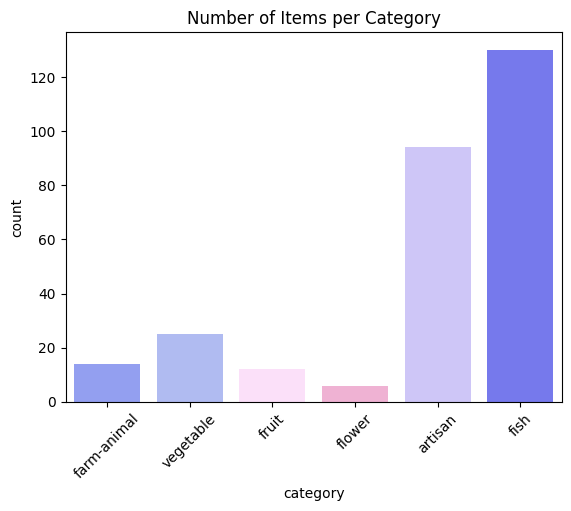

In [ ]:
final_df = final_df[final_df['category'] != 'resource']
final_df = final_df[final_df['category'] != 'seed']
final_df = final_df[final_df['category'] != 'special']

palette = {
  "artisan": "#C9BEFF",
  "fish": "#6367FF",
  "farm-animal": "#8494FF",
  "fruit": "#FFDBFD",
  "vegetable": "#A5B4FC",
  "flower": "#F9A8D4"
}

# Countplot for each category
sns.countplot(data=final_df, x='category', palette=palette)
plt.xticks(rotation=45)
plt.title("Number of Items per Category")
plt.show()


/tmp/ipykernel_14762/1196270901.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=final_df, x='harvest_frequency', palette='magma')


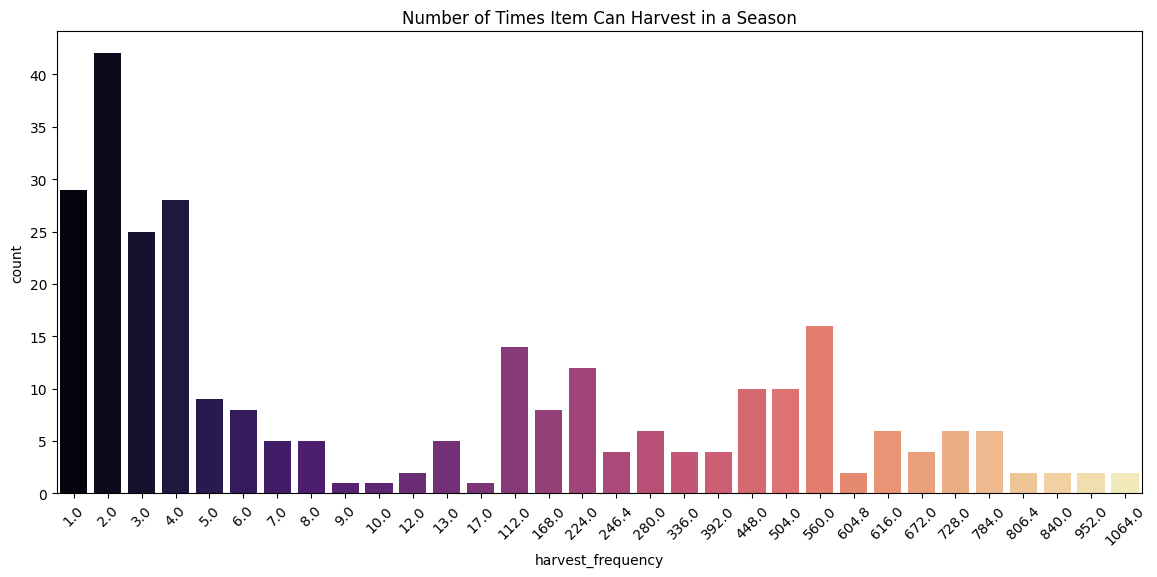

In [ ]:
# Countplot for harvest frequency
plt.figure(figsize=(14,6))

sns.countplot(data=final_df, x='harvest_frequency', palette='magma')

plt.xticks(rotation=45)

plt.title("Number of Times Item Can Harvest in a Season")

plt.show()

,name,id,category,seasons,growDays,regrowDays,sellPrice,harvest_frequency,harvest_quantity_average,silverPrice,goldPrice,iridiumPrice,difficulty,input_quantity
148,Starfruit Dried Fruit,DriedFruit,artisan,[summer],14.0,14.0,5650.0,2.0,1.0,0.0,0.0,0.0,NaN,5.0


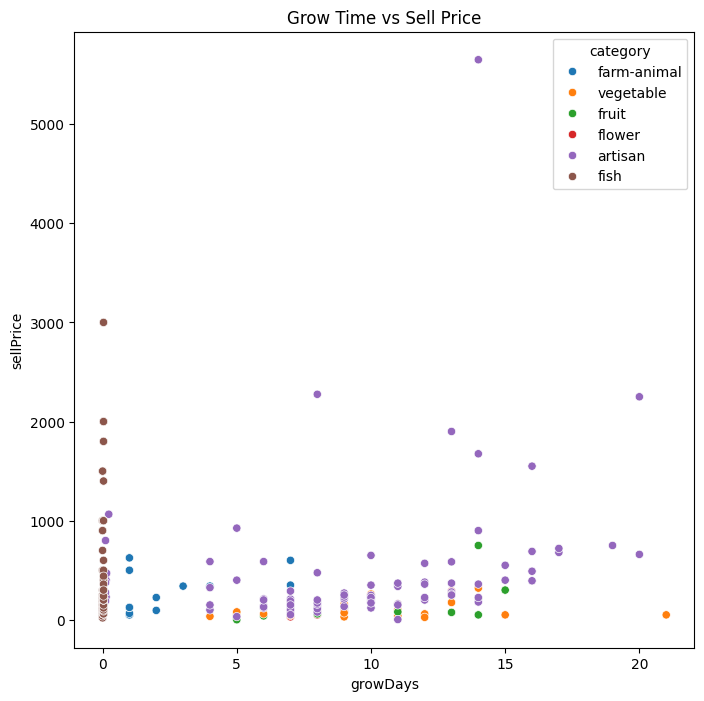

In [ ]:
# Scatterplot for growTime/sellPrice comparison
plt.figure(figsize=(8, 8))
sns.scatterplot(
    data=final_df,
    x='growDays',
    y='sellPrice',
    hue='category'
)

plt.title("Grow Time vs Sell Price")

# The most expensive item in the dataset
final_df[final_df['sellPrice'] == final_df['sellPrice'].max()]

In [ ]:
# Adding a values to the difficulty column. The less seasons available and the higher the growDays, the higher difficulty the item has

# Separating the number of seasons each item has. If it's empty, then assume you can get the item year round (4 seasons)
final_df['num_seasons'] = final_df['seasons'].apply(
    lambda x: len(x) if isinstance(x, list) else 4
    )

print(final_df['difficulty'].isna().sum())

# Originally scaled 5–110 based on fish dataset, but going to normalize to 0–1 for consistency
scaler = MinMaxScaler()

# Normalizing the data before the calculations to make them comparable
final_df['grow_scaled'] = scaler.fit_transform(final_df[['growDays']])
final_df['season_scaled'] = scaler.fit_transform(final_df[['num_seasons']])
final_df['price_scaled'] = scaler.fit_transform(final_df[['sellPrice']])
final_df['harvest_scaled'] = scaler.fit_transform(final_df[['harvest_frequency']])

# Added weights based off of what's more important. Price > growth > seasons
final_df['raw_difficulty'] = (
    0.7 * final_df['price_scaled'] +
    0.2 * final_df['grow_scaled'] +
    0.1 * (1 - final_df['season_scaled'])
)

# Fill difficulty values
# mask = final_df['difficulty'].isna()
# final_df.loc[mask, 'difficulty'] = final_df.loc[mask, 'raw_difficulty']
final_df['difficulty'] = final_df['raw_difficulty']

# Normalizing
final_df['difficulty'] = scaler.fit_transform(final_df[['difficulty']]).round(4)

final_df = final_df.drop(columns=['raw_difficulty', 'price_scaled', 'season_scaled', 'grow_scaled', 'harvest_scaled'])

final_df

161


,name,id,category,seasons,growDays,regrowDays,sellPrice,harvest_frequency,harvest_quantity_average,silverPrice,goldPrice,iridiumPrice,difficulty,input_quantity,num_seasons
0,White Chicken Egg,176,farm-animal,"[spring, summer, fall, winter]",1.000,2.000,50.0,13.0,1.0,62.0,75.0,100.0,0.0142,1.0,4
1,Brown Chicken Egg,180,farm-animal,"[spring, summer, fall, winter]",1.000,2.000,50.0,13.0,1.0,62.0,75.0,100.0,0.0142,1.0,4
2,Blue Chicken Egg,176,farm-animal,"[spring, summer, fall, winter]",1.000,2.000,50.0,13.0,1.0,62.0,75.0,100.0,0.0142,1.0,4
3,Void Chicken Egg,305,farm-animal,"[spring, summer, fall, winter]",1.000,2.000,65.0,13.0,1.0,81.0,97.0,130.0,0.0162,1.0,4
4,Golden Chicken Egg,982,farm-animal,"[spring, summer, fall, winter]",1.000,2.000,500.0,13.0,1.0,625.0,750.0,1000.0,0.0741,1.0,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
279,Smoked Son of Crimsonfish,SmokedFish,fish,[winter],0.035,0.035,3000.0,112.0,1.0,3750.0,4500.0,6000.0,0.5044,1.0,1
280,Smoked Ms. Angler,SmokedFish,fish,"[spring, summer, fall, winter]",0.035,0.035,1800.0,168.0,1.0,2250.0,2700.0,3600.0,0.2373,1.0,4
281,Smoked Radioactive Carp,SmokedFish,fish,"[spring, summer, fall, winter]",0.035,0.035,2000.0,224.0,1.0,2500.0,3000.0,4000.0,0.2639,1.0,4
282,Smoked Glacierfish Jr.,SmokedFish,fish,[winter],0.035,0.035,2000.0,112.0,1.0,2500.0,3000.0,4000.0,0.3713,1.0,1


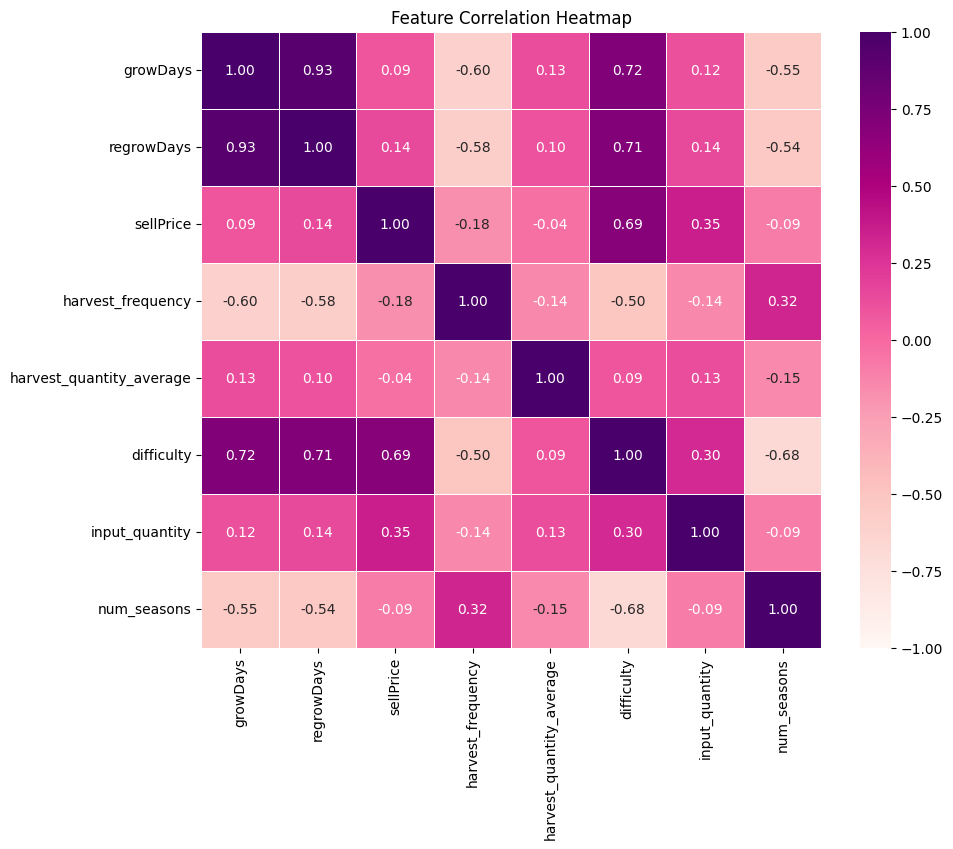

In [ ]:
plt.figure(figsize=(10, 8))

cols_to_drop = ['silverPrice', 'goldPrice', 'iridiumPrice']
clean_df = final_df.drop(columns=cols_to_drop)

sns.heatmap(clean_df.select_dtypes(include='number').corr(), annot=True, cmap='RdPu', vmin=-1, vmax=1, linewidths=0.55, fmt=".2f")

plt.title("Feature Correlation Heatmap")
plt.show()

In [ ]:
final_df["season_profit_normal"] = (
    final_df["sellPrice"]
    * final_df["harvest_frequency"]
    * final_df["harvest_quantity_average"]
)

final_df["season_profit_silver"] = (
    final_df["silverPrice"]
    * final_df["harvest_frequency"]
    * final_df["harvest_quantity_average"]
)

final_df["season_profit_gold"] = (
    final_df["goldPrice"]
    * final_df["harvest_frequency"]
    * final_df["harvest_quantity_average"]
)

final_df["season_profit_iridium"] = (
    final_df["iridiumPrice"]
    * final_df["harvest_frequency"]
    * final_df["harvest_quantity_average"]
)

In [ ]:
final_df

,name,id,category,seasons,growDays,regrowDays,sellPrice,harvest_frequency,harvest_quantity_average,silverPrice,goldPrice,iridiumPrice,difficulty,input_quantity,num_seasons,season_profit_normal,season_profit_silver,season_profit_gold,season_profit_iridium
0,White Chicken Egg,176,farm-animal,"[spring, summer, fall, winter]",1.000,2.000,50.0,13.0,1.0,62.0,75.0,100.0,0.0142,1.0,4,650.0,806.0,975.0,1300.0
1,Brown Chicken Egg,180,farm-animal,"[spring, summer, fall, winter]",1.000,2.000,50.0,13.0,1.0,62.0,75.0,100.0,0.0142,1.0,4,650.0,806.0,975.0,1300.0
2,Blue Chicken Egg,176,farm-animal,"[spring, summer, fall, winter]",1.000,2.000,50.0,13.0,1.0,62.0,75.0,100.0,0.0142,1.0,4,650.0,806.0,975.0,1300.0
3,Void Chicken Egg,305,farm-animal,"[spring, summer, fall, winter]",1.000,2.000,65.0,13.0,1.0,81.0,97.0,130.0,0.0162,1.0,4,845.0,1053.0,1261.0,1690.0
4,Golden Chicken Egg,982,farm-animal,"[spring, summer, fall, winter]",1.000,2.000,500.0,13.0,1.0,625.0,750.0,1000.0,0.0741,1.0,4,6500.0,8125.0,9750.0,13000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
279,Smoked Son of Crimsonfish,SmokedFish,fish,[winter],0.035,0.035,3000.0,112.0,1.0,3750.0,4500.0,6000.0,0.5044,1.0,1,336000.0,420000.0,504000.0,672000.0
280,Smoked Ms. Angler,SmokedFish,fish,"[spring, summer, fall, winter]",0.035,0.035,1800.0,168.0,1.0,2250.0,2700.0,3600.0,0.2373,1.0,4,302400.0,378000.0,453600.0,604800.0
281,Smoked Radioactive Carp,SmokedFish,fish,"[spring, summer, fall, winter]",0.035,0.035,2000.0,224.0,1.0,2500.0,3000.0,4000.0,0.2639,1.0,4,448000.0,560000.0,672000.0,896000.0
282,Smoked Glacierfish Jr.,SmokedFish,fish,[winter],0.035,0.035,2000.0,112.0,1.0,2500.0,3000.0,4000.0,0.3713,1.0,1,224000.0,280000.0,336000.0,448000.0


In [ ]:
# Best items per category based on quality
best_items_normal = final_df.loc[final_df.groupby("category")["season_profit_normal"].idxmax()]
best_items_silver = final_df.loc[final_df.groupby("category")["season_profit_silver"].idxmax()]
best_items_gold = final_df.loc[final_df.groupby("category")["season_profit_gold"].idxmax()]
best_items_iridium = final_df.loc[final_df.groupby("category")["season_profit_iridium"].idxmax()]

# Worst items per category based on quality
worst_items_normal = final_df.loc[final_df.groupby("category")["season_profit_normal"].idxmin()]
worst_items_silver = final_df.loc[final_df.groupby("category")["season_profit_silver"].idxmin()]
worst_items_gold = final_df.loc[final_df.groupby("category")["season_profit_gold"].idxmin()]
worst_items_iridium = final_df.loc[final_df.groupby("category")["season_profit_iridium"].idxmin()]

In [ ]:
# Creates a comparison table for best items across qualities
compare = pd.DataFrame({
    "normal": best_items_normal.set_index("category")["season_profit_normal"],
    "silver": best_items_silver.set_index("category")["season_profit_silver"],
    "gold": best_items_gold.set_index("category")["season_profit_gold"],
    "iridium": best_items_iridium.set_index("category")["season_profit_iridium"]
})
compare = compare.T

# Creates a comparison table for worst items across qualities
compare_worst = pd.DataFrame({
    "normal": worst_items_normal.set_index("category")["season_profit_normal"],
    "silver": worst_items_silver.set_index("category")["season_profit_silver"],
    "gold": worst_items_gold.set_index("category")["season_profit_gold"],
    "iridium": worst_items_iridium.set_index("category")["season_profit_iridium"]
})
compare_worst = compare_worst.T

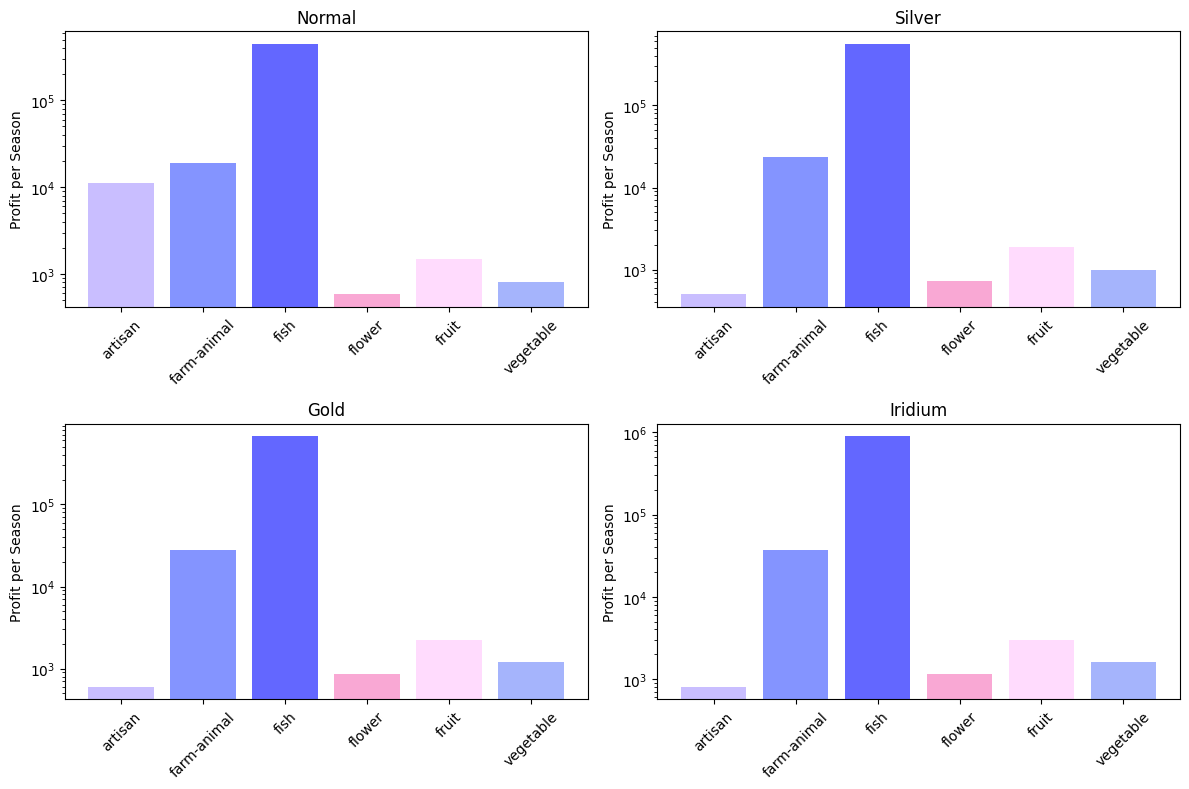

In [ ]:
colors = [palette[c] for c in best_items_normal["category"]]


# Plots Best items per category according to quality
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Normal
axes[0, 0].bar(best_items_normal["category"], best_items_normal["season_profit_normal"], color=colors)
axes[0, 0].set_title("Normal")
axes[0, 0].set_yscale("log")

# Silver
axes[0, 1].bar(best_items_silver["category"], best_items_silver["season_profit_silver"], color=colors)
axes[0, 1].set_title("Silver")
axes[0, 1].set_yscale("log")

# Gold
axes[1, 0].bar(best_items_gold["category"], best_items_gold["season_profit_gold"], color=colors)
axes[1, 0].set_title("Gold")
axes[1, 0].set_yscale("log")

# Iridium
axes[1, 1].bar(best_items_iridium["category"], best_items_iridium["season_profit_iridium"], color=colors)
axes[1, 1].set_title("Iridium")
axes[1, 1].set_yscale("log")

for ax in axes.flatten():
    ax.set_ylabel("Profit per Season")
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

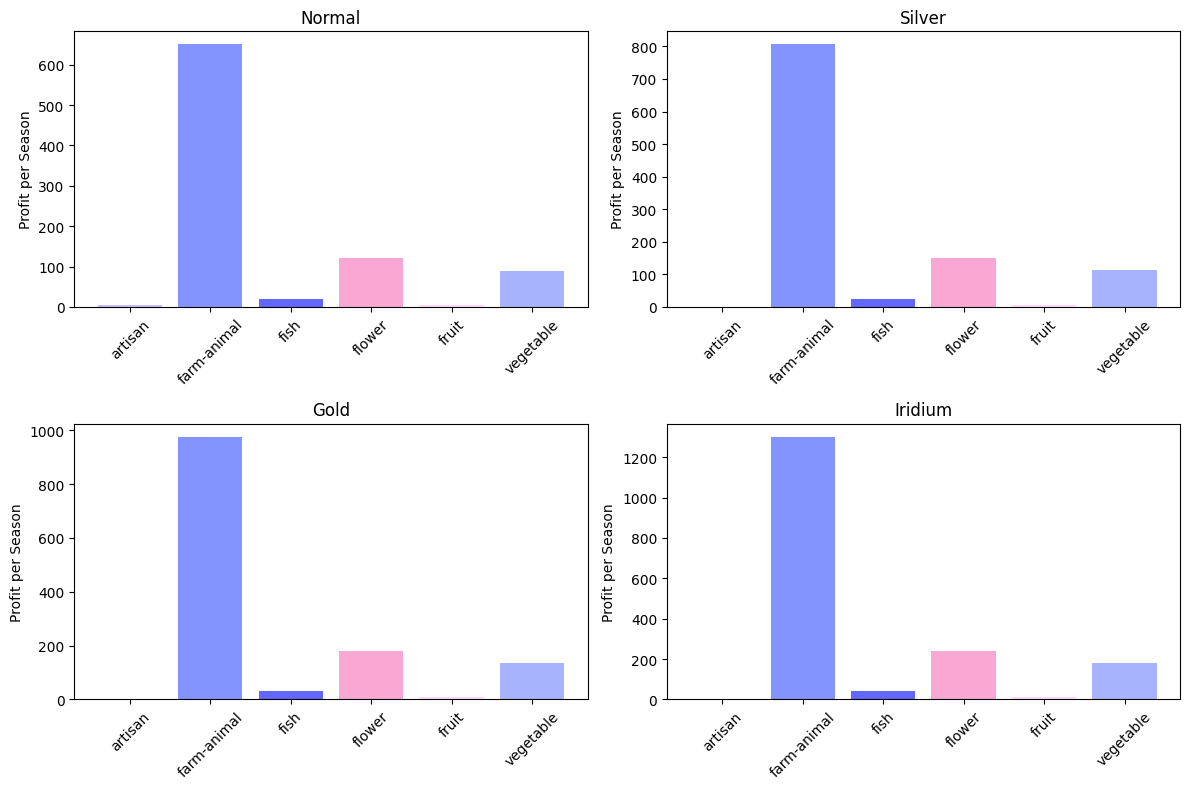

In [ ]:
# Plots Worst items per category according to quality
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Normal
axes[0, 0].bar(worst_items_normal["category"], worst_items_normal["season_profit_normal"], color=colors)
axes[0, 0].set_title("Normal")

# Silver
axes[0, 1].bar(worst_items_silver["category"], worst_items_silver["season_profit_silver"], color=colors)
axes[0, 1].set_title("Silver")

# Gold
axes[1, 0].bar(worst_items_gold["category"], worst_items_gold["season_profit_gold"], color=colors)
axes[1, 0].set_title("Gold")

# Iridium
axes[1, 1].bar(worst_items_iridium["category"], worst_items_iridium["season_profit_iridium"], color=colors)
axes[1, 1].set_title("Iridium")

for ax in axes.flatten():
    ax.set_ylabel("Profit per Season")
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Models

Imports

In [ ]:
import numpy as np
from xgboost import XGBRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

In [ ]:
y = final_df['season_profit_normal']
X = final_df.drop(columns=[
    'season_profit_normal',
    'season_profit_silver',
    'season_profit_gold',
    'season_profit_iridium',
    'name',
    'seasons',
    'goldPrice',
    'silverPrice',
    'iridiumPrice',
    "id"
])

X = pd.get_dummies(X, columns=['category'], drop_first=True)
X.columns

Index(['growDays', 'regrowDays', 'sellPrice', 'harvest_frequency',
       'harvest_quantity_average', 'difficulty', 'input_quantity',
       'num_seasons', 'category_farm-animal', 'category_fish',
       'category_flower', 'category_fruit', 'category_vegetable'],
      dtype='object')

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

### Models

In [ ]:
# Linear Regression
model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Linear Regression RMSE:", rmse)
print("Linear Regression R²:", r2)

Linear Regression RMSE: 49201.05150692194
Linear Regression R²: 0.6619150735694314




*   The R2 score of 0.66, indicating that Linear Regression shows approximately 79% of the variance in seasonal profit. This suggests a strong linear relationship between grow time, price, seasons, difficulty and profit
*   The RMSE score ~49,201 represents the average prediction error in profits. Due to the wide range of the profit distribution (0 to 448,000), this level of error is reasonable and expected
*    The model preforms well overall but it is likely less accurate for low profit items and is influenced more by high-profit outliers
*    The model is good but not perfect



In [ ]:
# Decision Tree
dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

rmse_dt = np.sqrt(mean_squared_error(y_test, y_pred_dt))
r2_dt = r2_score(y_test, y_pred_dt)

print("Decision Tree RMSE:", rmse_dt)
print("Decision Tree R²:", r2_dt)

Decision Tree RMSE: 14579.691854882714
Decision Tree R²: 0.970312492988302


The Decision Tree model achieved a high R² score of approximately 0.97 and a relatively low RMSE of around ~14,579, indicating strong predictive performance. However, the model was trained without constraints, allowing it to fully grow and capture complex patterns in the data. While this results in high accuracy, it also increases the risk of overfitting, as the model may be memorizing the training data rather than generalizing well to unseen data. This is further supported by the hyperparameter tuning results, which selected the same unconstrained configuration

In [ ]:
# Random Forest
rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest RMSE:", rmse_rf)
print("Random Forest R²:", r2_rf)

Random Forest RMSE: 14374.795306205877
Random Forest R²: 0.9711410598493436


The Random Forest model achieved an R² score of approximately 0.971 and an RMSE of around ~14,374. While this performance is slightly lower than the Decision Tree, Random Forest is generally more robust due to its ensemble nature. By combining multiple trees and averaging their predictions, it reduces overfitting and improves generalization. The slightly higher error suggests that the model avoids memorizing the data and instead captures more general patterns, making it more reliable for predicting unseen data.

In [ ]:
# Gradient Boosting
gb_model = GradientBoostingRegressor(random_state=42)
gb_model.fit(X_train, y_train)

y_pred_gb = gb_model.predict(X_test)

rmse_gb = np.sqrt(mean_squared_error(y_test, y_pred_gb))
r2_gb = r2_score(y_test, y_pred_gb)

print("Gradient Boosting RMSE:", rmse_gb)
print("Gradient Boosting R²:", r2_gb)

Gradient Boosting RMSE: 8590.277196175424
Gradient Boosting R²: 0.9896939701625933


The Gradient Boosting model achieved the best performance, with an R² score of approximately 0.989 and the lowest RMSE of around 8,590. This indicates that the model explains most of the variance in seasonal profit while maintaining low prediction error. Gradient Boosting builds trees sequentially, with each new tree correcting the errors of the previous one. This allows the model to capture complex non-linear relationships while avoiding overfitting. Compared to the Decision Tree and Random Forest, Gradient Boosting provides the best balance so far between accuracy and generalization.

In [ ]:
# XGBoost
xgb_model = XGBRegressor(random_state=42)

xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)

rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2_xgb = r2_score(y_test, y_pred_xgb)

print("XGBoost RMSE:", rmse_xgb)
print("XGBoost R²:", r2_xgb)

XGBoost RMSE: 7134.6323378901425
XGBoost R²: 0.9928908081373949


The XGBoost model achieved an R² score of approximately 0.99 and an RMSE of around ~7,134, performing similarly to the Random Forest model. While XGBoost is an optimized boosting algorithm, it did not outperform Gradient Boosting in this case. The model's increased complexity, particularly with deeper trees, may have led to slight overfitting, reducing its ability to generalize. This highlights that more advanced models do not always yield better performance, and simpler configurations can sometimes be more effective depending on the dataset.

### Feature Importance

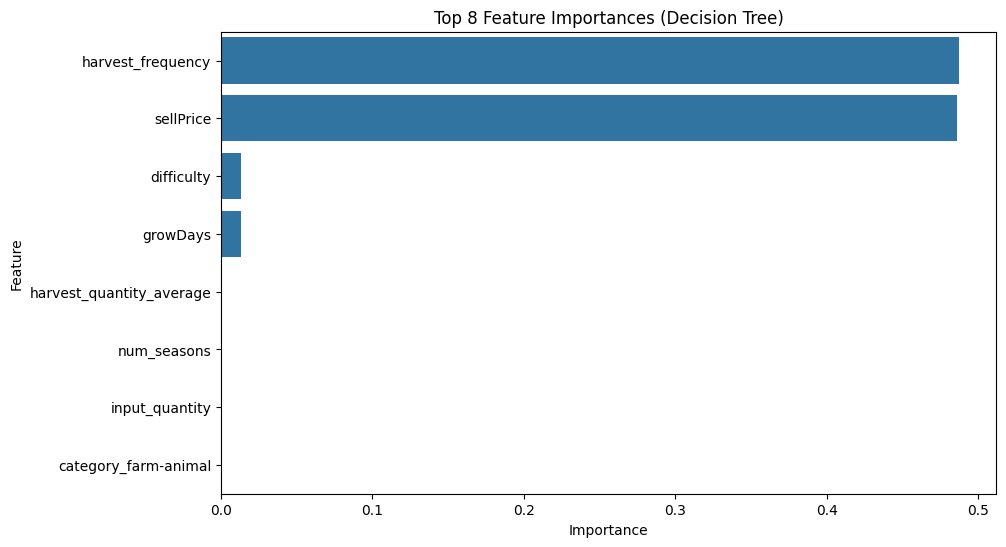

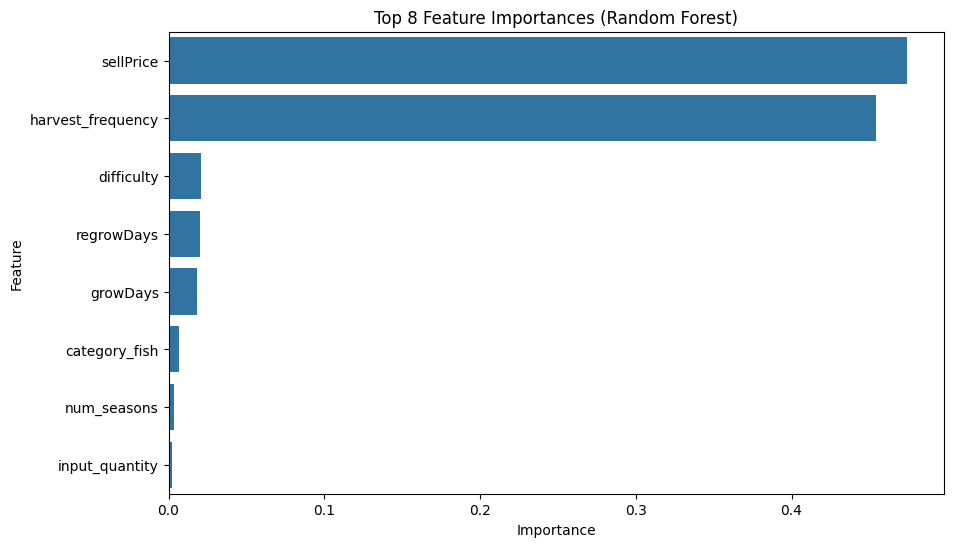

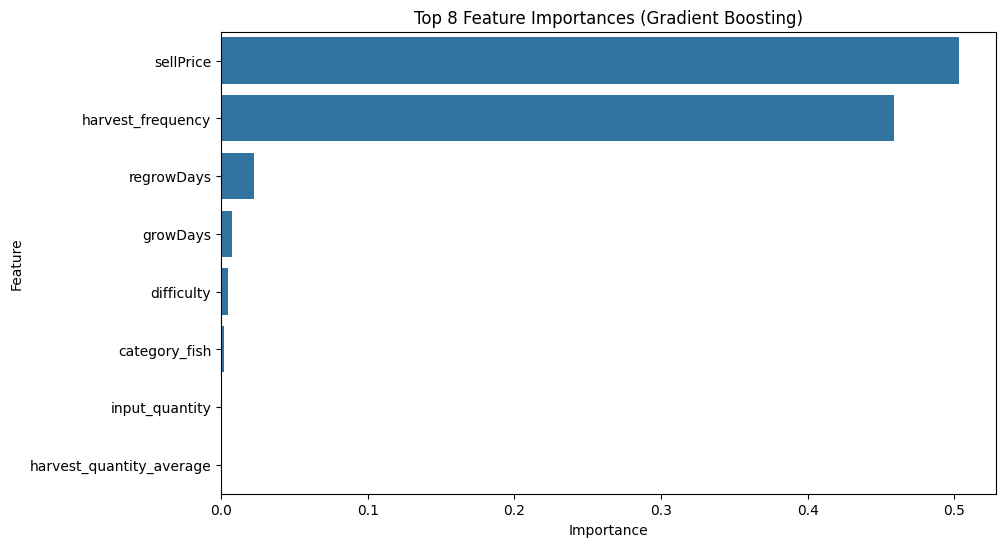

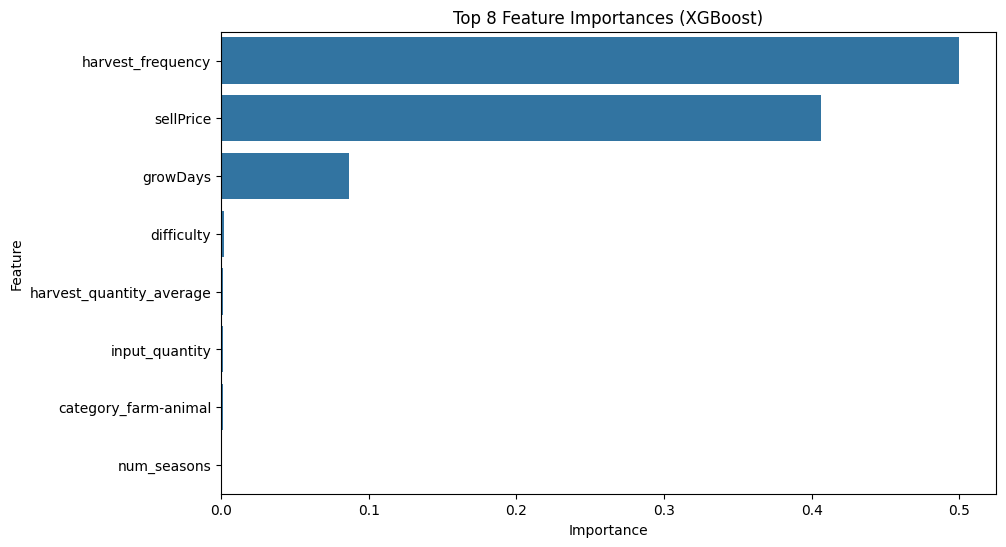

In [ ]:
models = {
    # "Linear Regression": model, Removing since LR Doesnt have a feature_importance attribute
    "Decision Tree": dt_model,
    "Random Forest": rf_model,
    "Gradient Boosting": gb_model,
    "XGBoost": xgb_model
}

for name, model in models.items():

    importances = model.feature_importances_
    feature_names = X_train.columns

    # Sort and take top 8
    top10 = pd.DataFrame({"Feature": feature_names,"Importance": importances}).sort_values(by="Importance", ascending=False).head(8)

    plt.figure(figsize=(10, 6))
    sns.barplot(data=top10, x='Importance', y='Feature')
    plt.title(f"Top 8 Feature Importances ({name})")
    plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.show()

### Hyperparameters

In [ ]:
param_grid_dt = {
    "max_depth": [None, 5, 10],
    "min_samples_split": [2, 5, 10]
}

grid_search_dt = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    param_grid_dt,
    cv=3,
    n_jobs=-1,
    scoring="r2"
)

grid_search_dt.fit(X_train, y_train)

best_dt = grid_search_dt.best_estimator_

y_pred_best_dt = best_dt.predict(X_test)

rmse_best_dt = np.sqrt(mean_squared_error(y_test, y_pred_best_dt))
r2_best_dt = r2_score(y_test, y_pred_best_dt)

print("Best Params:", grid_search_dt.best_params_)
print("Tuned RMSE:", rmse_best_dt)
print("Tuned R²:", r2_best_dt)

Best Params: {'max_depth': 10, 'min_samples_split': 2}
Tuned RMSE: 10383.152530091696
Tuned R²: 0.9849431020462208


We used GridSearchCV to optimize the Decision Tree Regressor hyperparameters by testing different combinations of maximum tree depth and minimum sample split values. The best-performing configuration used a maximum depth of 10 and a minimum sample split of 2.

After tuning, the model achieved an RMSE of approximately 10,383 and an R² score of about 0.985. This indicates that the tuned model was able to explain roughly 98.5% of the variance in seasonal profitability while maintaining relatively low prediction error.

Compared to the untuned version, hyperparameter tuning improved the model’s ability to capture more complex relationships between gameplay features and profitability without excessively limiting the tree structure. The deeper tree depth allowed the model to better separate different gameplay and economic patterns across Stardew Valley item categories.

In [ ]:
param_grid_rf = {
    "n_estimators": [50, 100],
    "max_depth": [None, 5, 10],
}

grid_search_rf = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid_rf,
    cv=3,
    n_jobs=-1,
    scoring="r2"
)

grid_search_rf.fit(X_train, y_train)

best_rf = grid_search_rf.best_estimator_

y_pred_best_rf = best_rf.predict(X_test)

rmse_best_rf = np.sqrt(mean_squared_error(y_test, y_pred_best_rf))
r2_best_rf = r2_score(y_test, y_pred_best_rf)

print("Best Params:", grid_search_rf.best_params_)
print("Tuned RMSE:", rmse_best_rf)
print("Tuned R²:", r2_best_rf)

Best Params: {'max_depth': 10, 'n_estimators': 50}
Tuned RMSE: 12883.481750588911
Tuned R²: 0.9768183933452755


We used GridSearchCV to optimize the Random Forest Regressor by testing different combinations of tree depth and the number of estimators in the ensemble. The best-performing configuration used a maximum depth of 10 with 50 decision trees.

After tuning, the model achieved an RMSE of approximately 12,883 and an R² score of about 0.977. This indicates that the Random Forest model was able to explain roughly 97.7% of the variance in seasonal profitability while maintaining strong predictive performance across the dataset.

Compared to a single decision tree, the Random Forest combines predictions from multiple trees, which helps reduce overfitting and improve generalization. The tuned depth of 10 allowed the model to capture complex gameplay and profitability relationships while still maintaining more stable predictions across different Stardew Valley item categories.

In [ ]:
param_grid_gb = {
    'n_estimators': [50, 100],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 5]
}

grid_search_gb = GridSearchCV(
    GradientBoostingRegressor(random_state=42),
    param_grid_gb,
    cv=3,
    n_jobs=-1,
    scoring="r2"
)

grid_search_gb.fit(X_train, y_train)

best_gb = grid_search_gb.best_estimator_

y_pred_best_gb = best_gb.predict(X_test)

rmse_best_gb = np.sqrt(mean_squared_error(y_test, y_pred_best_gb))
r2_best_gb = r2_score(y_test, y_pred_best_gb)

print("Best Params:", grid_search_gb.best_params_)
print("Tuned RMSE:", rmse_best_gb)
print("Tuned R²:", r2_best_gb)

Best Params: {'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 100}
Tuned RMSE: 8328.09621747556
Tuned R²: 0.9903134637650894


We used GridSearchCV to optimize the Gradient Boosting Regressor by testing different combinations of learning rate, tree depth, and the number of estimators. The best-performing configuration used a learning rate of 0.05, a maximum depth of 5, and 100 estimators.

After tuning, the model achieved an RMSE of approximately 8,328 and an R² score of about 0.990, making it one of the strongest-performing models in the project. This indicates that the model was able to explain roughly 99.0% of the variance in seasonal profitability while maintaining very low prediction error.

Unlike Random Forest, which builds many independent trees, Gradient Boosting builds trees sequentially, where each new tree attempts to correct the errors made by the previous ones. The lower learning rate allowed the model to learn more gradually and reduce overfitting, while the larger number of estimators helped improve overall prediction accuracy across different Stardew Valley gameplay categories.

In [ ]:
param_grid_xgb = {
    'n_estimators': [50, 100],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 5]
}

grid_search_xgb = GridSearchCV(
    XGBRegressor(random_state=42),
    param_grid_xgb,
    cv=3,
    n_jobs=-1,
    scoring="r2"
)

grid_search_xgb.fit(X_train, y_train)

best_xgb = grid_search_xgb.best_estimator_

y_pred_best_xgb = best_xgb.predict(X_test)

rmse_best_xgb = np.sqrt(mean_squared_error(y_test, y_pred_best_xgb))
r2_best_xgb = r2_score(y_test, y_pred_best_xgb)

print("Best Params:", grid_search_xgb.best_params_)
print("Tuned RMSE:", rmse_best_xgb)
print("Tuned R²:", r2_best_xgb)

Best Params: {'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 50}
Tuned RMSE: 19025.609526402055
Tuned R²: 0.9494461544043787


We used GridSearchCV to optimize the XGBoost Regressor by testing different combinations of learning rate, tree depth, and the number of estimators. The best-performing configuration used a learning rate of 0.05, a maximum depth of 5, and 50 estimators.

After tuning, the model achieved an RMSE of approximately 19,026 and an R² score of about 0.949. This indicates that the model was able to explain roughly 94.9% of the variance in seasonal profitability, although it produced higher prediction error compared to several of the other tuned ensemble models.

Similar to Gradient Boosting, XGBoost builds trees sequentially and attempts to correct errors from previous trees during training. However, after removing several influential gameplay outliers from the dataset, the tuned XGBoost model became more sensitive to the remaining data distribution and did not generalize as effectively as the other ensemble approaches. Despite this, the model still demonstrated strong overall predictive performance and was able to capture many complex nonlinear gameplay and profitability relationships.

# Game File Comparison

With 70 hours game time

In [ ]:
tree = ET.parse(game_file)
root = tree.getroot()

# find the main basicShipped section
basic_shipped = root.findall(".//basicShipped")

shipped_data = []

for player_num, basic_shipped in enumerate(basic_shipped, start=1):
    for item in basic_shipped.findall("item"):
        item_id = item.find("key/string").text
        quantity_sold = int(item.find("value/int").text)

        shipped_data.append({
            "id": item_id,
            "quantity_sold": quantity_sold
        })

game_df = pd.DataFrame(shipped_data)
game_df = (game_df.groupby('id', as_index=False)['quantity_sold'].sum())

game_df

,id,quantity_sold
0,129,28
1,130,50
2,131,74
3,132,94
4,136,57
...,...,...
90,881,18
91,92,39
92,DriedFruit,53
93,SkillBook_1,2


In [ ]:
game_df = game_df[game_df["id"] != "SkillBook_1"]

merged_df = pd.merge(
    final_df,
    game_df,
    on="id",
    how="left"
)

merged_df

,name,id,category,seasons,growDays,regrowDays,sellPrice,harvest_frequency,harvest_quantity_average,silverPrice,goldPrice,iridiumPrice,difficulty,input_quantity,num_seasons,season_profit_normal,season_profit_silver,season_profit_gold,season_profit_iridium,quantity_sold
0,White Chicken Egg,176,farm-animal,"[spring, summer, fall, winter]",1.000,2.000,50.0,13.0,1.0,62.0,75.0,100.0,0.0142,1.0,4,650.0,806.0,975.0,1300.0,NaN
1,Brown Chicken Egg,180,farm-animal,"[spring, summer, fall, winter]",1.000,2.000,50.0,13.0,1.0,62.0,75.0,100.0,0.0142,1.0,4,650.0,806.0,975.0,1300.0,NaN
2,Blue Chicken Egg,176,farm-animal,"[spring, summer, fall, winter]",1.000,2.000,50.0,13.0,1.0,62.0,75.0,100.0,0.0142,1.0,4,650.0,806.0,975.0,1300.0,NaN
3,Void Chicken Egg,305,farm-animal,"[spring, summer, fall, winter]",1.000,2.000,65.0,13.0,1.0,81.0,97.0,130.0,0.0162,1.0,4,845.0,1053.0,1261.0,1690.0,NaN
4,Golden Chicken Egg,982,farm-animal,"[spring, summer, fall, winter]",1.000,2.000,500.0,13.0,1.0,625.0,750.0,1000.0,0.0741,1.0,4,6500.0,8125.0,9750.0,13000.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
276,Smoked Son of Crimsonfish,SmokedFish,fish,[winter],0.035,0.035,3000.0,112.0,1.0,3750.0,4500.0,6000.0,0.5044,1.0,1,336000.0,420000.0,504000.0,672000.0,819.0
277,Smoked Ms. Angler,SmokedFish,fish,"[spring, summer, fall, winter]",0.035,0.035,1800.0,168.0,1.0,2250.0,2700.0,3600.0,0.2373,1.0,4,302400.0,378000.0,453600.0,604800.0,819.0
278,Smoked Radioactive Carp,SmokedFish,fish,"[spring, summer, fall, winter]",0.035,0.035,2000.0,224.0,1.0,2500.0,3000.0,4000.0,0.2639,1.0,4,448000.0,560000.0,672000.0,896000.0,819.0
279,Smoked Glacierfish Jr.,SmokedFish,fish,[winter],0.035,0.035,2000.0,112.0,1.0,2500.0,3000.0,4000.0,0.3713,1.0,1,224000.0,280000.0,336000.0,448000.0,819.0


In [ ]:
graph_df = merged_df.drop_duplicates(subset="id", keep="first").copy()

graph_df.loc[graph_df["id"] == "SmokedFish", "name"] = "Smoked Fish"
graph_df.loc[graph_df["id"] == "DriedFruit", "name"] = "Dried Fruit"
graph_df.loc[graph_df["id"] == "Jelly", "name"] = "Jelly"

In [ ]:
graph_df

,name,id,category,seasons,growDays,regrowDays,sellPrice,harvest_frequency,harvest_quantity_average,silverPrice,goldPrice,iridiumPrice,difficulty,input_quantity,num_seasons,season_profit_normal,season_profit_silver,season_profit_gold,season_profit_iridium,quantity_sold
0,White Chicken Egg,176,farm-animal,"[spring, summer, fall, winter]",1.000,2.000,50.0,13.0,1.0,62.0,75.0,100.0,0.0142,1.0,4,650.0,806.0,975.0,1300.0,NaN
1,Brown Chicken Egg,180,farm-animal,"[spring, summer, fall, winter]",1.000,2.000,50.0,13.0,1.0,62.0,75.0,100.0,0.0142,1.0,4,650.0,806.0,975.0,1300.0,NaN
3,Void Chicken Egg,305,farm-animal,"[spring, summer, fall, winter]",1.000,2.000,65.0,13.0,1.0,81.0,97.0,130.0,0.0162,1.0,4,845.0,1053.0,1261.0,1690.0,NaN
4,Golden Chicken Egg,982,farm-animal,"[spring, summer, fall, winter]",1.000,2.000,500.0,13.0,1.0,625.0,750.0,1000.0,0.0741,1.0,4,6500.0,8125.0,9750.0,13000.0,NaN
5,Duck Egg,442,farm-animal,"[spring, summer, fall, winter]",2.000,3.000,95.0,8.0,1.0,118.0,142.0,190.0,0.0304,1.0,4,760.0,944.0,1136.0,1520.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
218,Ms. Angler,899,fish,"[spring, summer, fall, winter]",0.000,0.000,900.0,168.0,1.0,1125.0,1350.0,1800.0,0.1171,1.0,4,151200.0,189000.0,226800.0,302400.0,NaN
219,Radioactive Carp,901,fish,"[spring, summer, fall, winter]",0.000,0.000,1000.0,224.0,1.0,1250.0,1500.0,2000.0,0.1304,1.0,4,224000.0,280000.0,336000.0,448000.0,NaN
220,Glacierfish Jr.,902,fish,[winter],0.000,0.000,1000.0,112.0,1.0,1250.0,1500.0,2000.0,0.2379,1.0,1,112000.0,140000.0,168000.0,224000.0,NaN
221,Goby,Goby,fish,"[spring, summer, fall]",0.000,0.000,150.0,504.0,1.0,187.0,225.0,300.0,0.0531,1.0,3,75600.0,94248.0,113400.0,151200.0,NaN


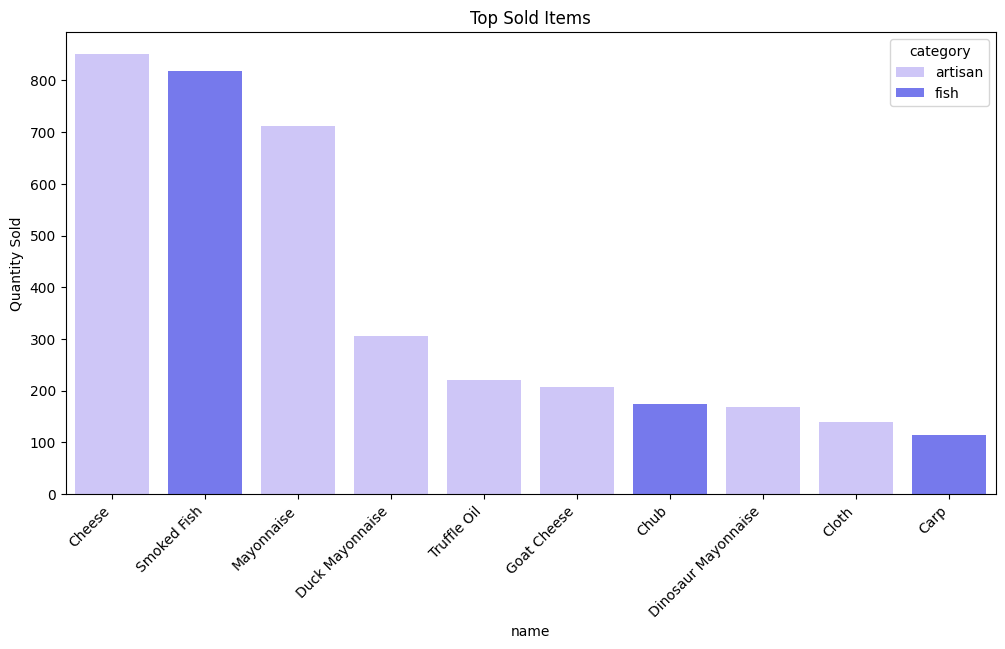

In [ ]:
top_items = graph_df.sort_values("quantity_sold", ascending=False).head(10)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=top_items,
    x="name",
    y="quantity_sold",
    hue="category",
    palette=palette
)

plt.xticks(rotation=45, ha="right")

plt.ylabel("Quantity Sold")
plt.title("Top Sold Items")

plt.show()

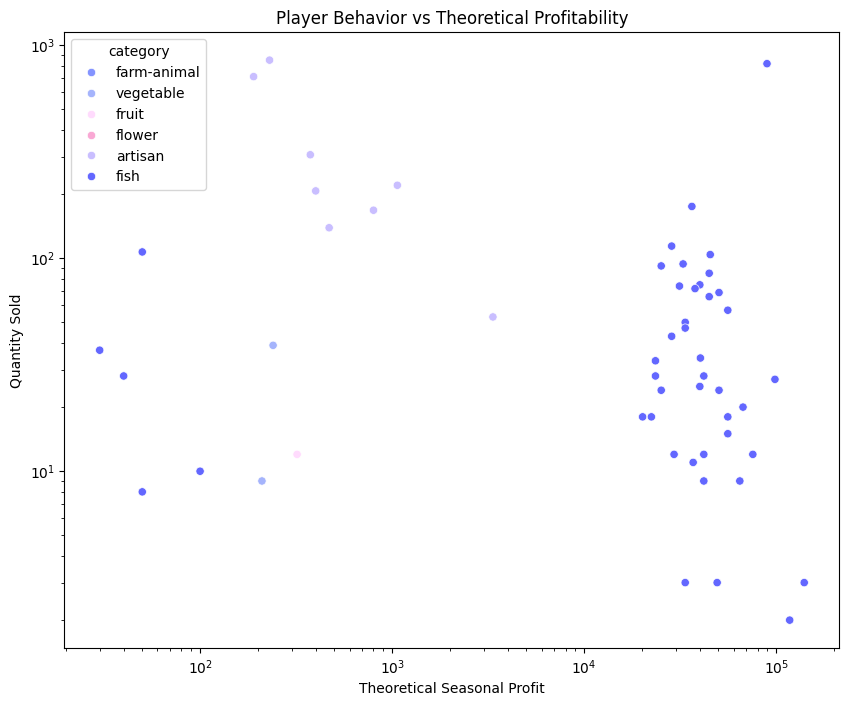

In [ ]:
plt.figure(figsize=(10, 8))

sns.scatterplot(
    data=graph_df,
    x="season_profit_normal",
    y="quantity_sold",
    hue="category",
    palette=palette
)

plt.xscale("log")
plt.yscale("log")

plt.xlabel("Theoretical Seasonal Profit")
plt.ylabel("Quantity Sold")

plt.title("Player Behavior vs Theoretical Profitability")

plt.show()

In [ ]:
graph_df["actual_estimated_revenue"] = (
    graph_df["quantity_sold"] *
    graph_df["sellPrice"]
)

top_revenue = graph_df.sort_values(
    "actual_estimated_revenue",
    ascending=False
).head(10)

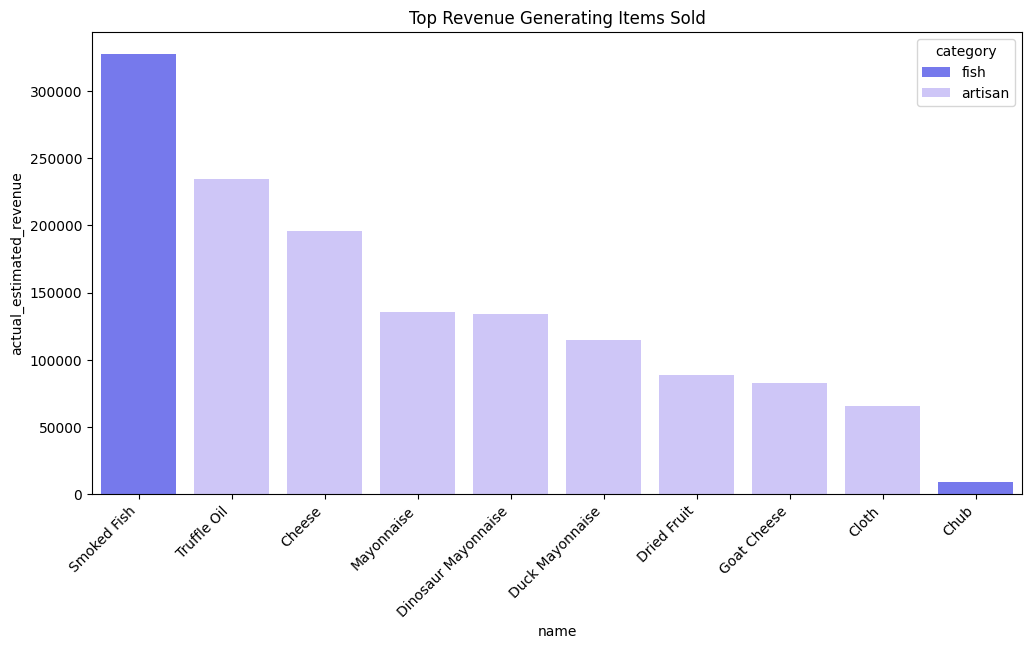

In [ ]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=top_revenue,
    x="name",
    y="actual_estimated_revenue",
    hue="category",
    palette=palette
)

plt.xticks(rotation=45, ha="right")
plt.title("Top Revenue Generating Items Sold")

plt.show()

In [ ]:
category_revenue = (
    graph_df
    .groupby("category")["actual_estimated_revenue"]
    .sum()
    .reset_index()
)

category_revenue

,category,actual_estimated_revenue
0,artisan,1051365.0
1,farm-animal,0.0
2,fish,450485.0
3,flower,0.0
4,fruit,480.0
5,vegetable,1875.0


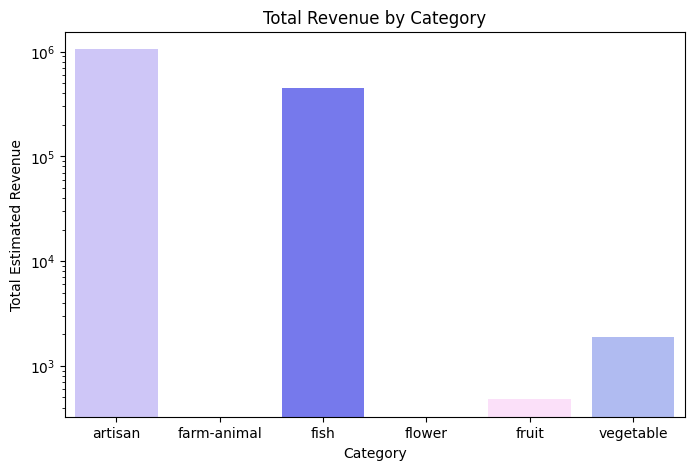

In [ ]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=category_revenue,
    x="category",
    y="actual_estimated_revenue",
    hue="category",
    palette=palette
)

plt.xlabel("Category")
plt.ylabel("Total Estimated Revenue")
plt.title("Total Revenue by Category")

plt.yscale("log")

plt.show()

### K-means


In [282]:
cluster_features = final_df[[
    'sellPrice',
    'growDays',
    'harvest_frequency',
    'difficulty',
    'num_seasons',
    'harvest_quantity_average',
    'season_profit_normal'
]]

scaled_features = scaler.fit_transform(cluster_features)

In [283]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42
)

clusters = kmeans.fit_predict(scaled_features)

In [284]:
final_df['cluster'] = clusters

final_df.groupby('cluster')[[
    'sellPrice',
    'growDays',
    'difficulty',
    'harvest_frequency',
    'season_profit_normal'
]].mean()

,sellPrice,growDays,difficulty,harvest_frequency,season_profit_normal
cluster,,,,,
0,464.747899,9.379622,0.257748,12.436975,15300.000000
1,318.760870,1.075598,0.051929,247.680435,60911.250000
2,244.375000,8.166667,0.214850,4.000000,3239.583333
3,180.775862,0.017500,0.096891,515.972414,66707.586207


In [285]:
pca = PCA(n_components=2)

pca_result = pca.fit_transform(scaled_features)

PCA was used to reduce the high-dimensional gameplay feature space into two dimensions for visualization while preserving as much variance as possible.


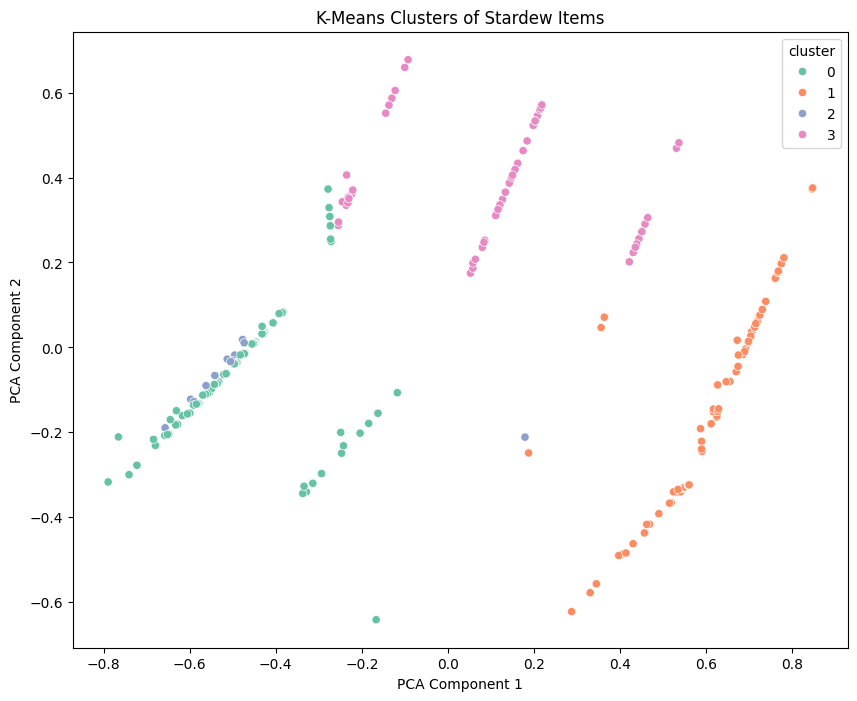

In [286]:
plt.figure(figsize=(10, 8))

sns.scatterplot(
    x=pca_result[:,0],
    y=pca_result[:,1],
    hue=final_df['cluster'],
    palette='Set2'
)

plt.title("K-Means Clusters of Stardew Items")

plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")

plt.show()

In [288]:
cluster_names = {
    0: "Traditional Farming",
    1: "Farm Animal Economy",
    2: "Processed Artisan Economy",
    3: "Fishing Economy"
}

for i, name in cluster_names.items():
    print(f"\nCLUSTER {i}: {name}")
    print(
        final_df[final_df['cluster'] == i][[
            'name',
            'category',
            'sellPrice',
            'difficulty',
            'season_profit_normal'
        ]].head(10)
    )


CLUSTER 0: Traditional Farming
             name   category  sellPrice  difficulty  season_profit_normal
14        Parsnip  vegetable       35.0      0.1606                 210.0
15     Green Bean  vegetable       40.0      0.2226                 240.0
16    Cauliflower  vegetable      175.0      0.2610                 350.0
18         Garlic  vegetable       60.0      0.1639                 360.0
19           Kale  vegetable      110.0      0.1910                 440.0
20        Rhubarb      fruit      220.0      0.2773                 440.0
21     Strawberry      fruit      120.0      0.2128                 600.0
22  Unmilled Rice  vegetable       30.0      0.2008                  90.0
23          Tulip     flower       30.0      0.1804                 120.0
24      Blue Jazz     flower       50.0      0.1932                 150.0

CLUSTER 1: Farm Animal Economy
                 name     category  sellPrice  difficulty  \
0   White Chicken Egg  farm-animal       50.0      0.0142   


We applied K-Means clustering to identify hidden gameplay/economic archetypes among Stardew items using engineered gameplay features

<br>

**Cluster 0: Standard Seasonal Crops - conventional seasonal farming.**
  - Characteristics:
      - lower profits
      - traditional farming
      - normal crop economy
      - beginner/mid-game growth
  - Examples:
      - Parsnip
      - Kale
      - Tulip
      - Garlic

**Cluster 1: Farm Animal Economy**
  - Characteristics:
    - consistent production
    - low difficulty
    - medium/high profitability
    - passive-ish income
  - Examples:
    - Eggs
    - Milk
    - Wool


**Cluster 2: High-Efficiency Processed Goods**
  - Characteristics:
      - artisan-heavy
      - regrowth crops
      - processing chains
      - high optimization economy
      - Examples:
        - Blueberry Wine
        - Cranberry Jelly
        - Potato Pickles

**Cluster 3: Fishing Economy**
  - Characteristics:
      - extremely high seasonal profit totals
      - very high harvest frequency
      - lower grow/setup time compared to farming systems
      - focused on volume and repetition rather than processing chains
      - moderate sell prices but large overall profit due to catch frequency
      - Examples:
          - Tuna
          - Salmon
          - Walleye
          - Pike
          - Rainbow Trout

  

### Strategy Classification + Recommendation Demo


In [ ]:
def assign_strategy(row):
    if row["difficulty"] <= 0.10 and row["season_profit_normal"] >= 1000:
        return "Beginner Friendly"
    elif row["harvest_frequency"] >= 10:
        return "High Volume"
    elif row["category"] == "artisan":
        return "Processed Artisan"
    elif row["growDays"] <= 7 and row["season_profit_normal"] >= 300:
        return "Fast Cash"
    elif row["season_profit_normal"] >= final_df["season_profit_normal"].quantile(0.75):
        return "High Profit"
    else:
        return "Standard Farming"

final_df["strategy_type"] = final_df.apply(assign_strategy, axis=1)

final_df[["name", "category", "season_profit_normal", "difficulty", "strategy_type"]].head(15)

,name,category,season_profit_normal,difficulty,strategy_type
0,White Chicken Egg,farm-animal,650.0,0.0142,High Volume
1,Brown Chicken Egg,farm-animal,650.0,0.0142,High Volume
2,Blue Chicken Egg,farm-animal,650.0,0.0142,High Volume
3,Void Chicken Egg,farm-animal,845.0,0.0162,High Volume
4,Golden Chicken Egg,farm-animal,6500.0,0.0741,Beginner Friendly
5,Duck Egg,farm-animal,760.0,0.0304,Fast Cash
6,Rabbit Wool,farm-animal,1700.0,0.0835,Beginner Friendly
7,Dinosaur Egg,farm-animal,1400.0,0.1155,Fast Cash
8,White Cow Milk,farm-animal,1500.0,0.0242,Beginner Friendly
9,Brown Cow Milk,farm-animal,1500.0,0.0242,Beginner Friendly


/tmp/ipykernel_14762/2357816569.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=final_df, y="strategy_type", order=final_df["strategy_type"].value_counts().index, palette="magma")


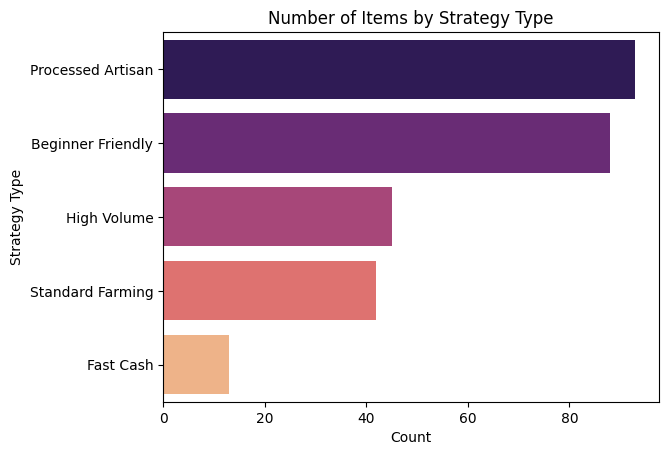

In [ ]:
sns.countplot(data=final_df, y="strategy_type", order=final_df["strategy_type"].value_counts().index, palette="magma")

plt.title("Number of Items by Strategy Type")

plt.xlabel("Count")
plt.ylabel("Strategy Type")

plt.show()